Fig 1

SVG saved as arena_map.svg


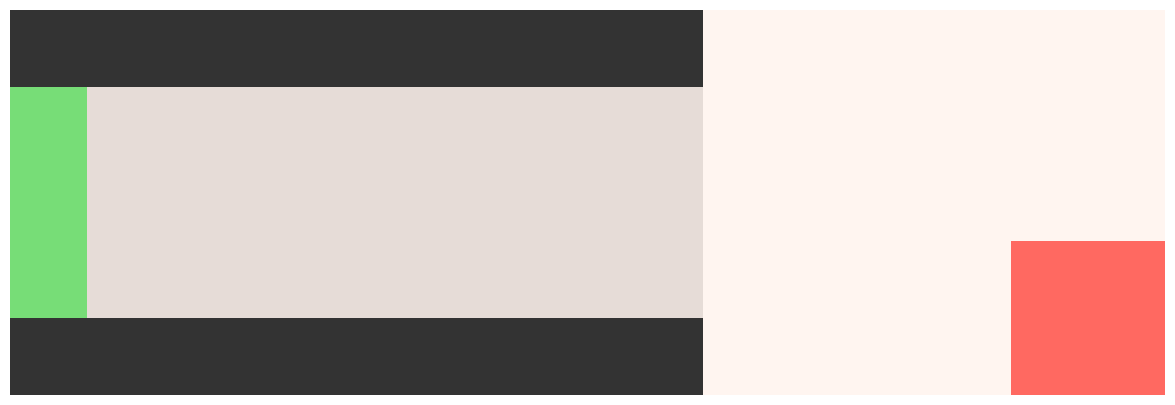

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter"],   # or Helvetica, DejaVu Sans
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "svg.fonttype": "none",          # keep text editable
})
# 1. Setup the Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. Settings
rows, cols = mask.shape

# Revised Palette (Normalized to 0-1 for Matplotlib)
def hex_to_rgb(r, g, b):
    return (r/255, g/255, b/255)

colors = {
    'wall':           hex_to_rgb(51, 51, 51),
    'shelter':        hex_to_rgb(119, 221, 119),
    'threat':         hex_to_rgb(255, 105, 97),
    'floor_corridor': hex_to_rgb(230, 220, 215),
    'floor_chamber':  hex_to_rgb(255, 245, 240)
}

# 3. Create Figure
# We set the aspect ratio to match the mask dimensions
fig, ax = plt.subplots(figsize=(cols, rows))
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.set_aspect('equal')
ax.axis('off')  # Hide axes for a clean map

# 4. Draw the Grid
for r in range(rows):
    for c in range(cols):
        # Determine Color
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:
            fill = colors['shelter']
        elif c >= 13 and r >= 3:
            fill = colors['threat']
        else:
            if c <= 8:
                fill = colors['floor_corridor']
            else:
                fill = colors['floor_chamber']
        
        # Matplotlib's (0,0) is bottom-left, PIL's is top-left.
        # To match your PIL output, we flip the row index:
        y_pos = rows - 1 - r
        
        # Add a borderless rectangle patch
        rect = patches.Rectangle((c, y_pos), 1, 1, facecolor=fill, edgecolor='none')
        ax.add_patch(rect)

# 5. Save as SVG
plt.savefig("arena_map.svg", format='svg', bbox_inches='tight', pad_inches=0)
print("SVG saved as arena_map.svg")
plt.show()

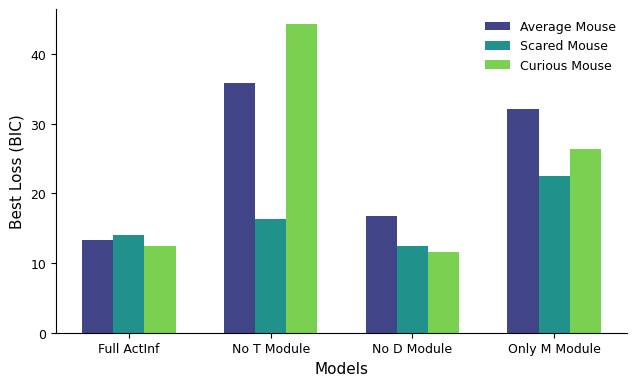

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# -------------------------
# Replace with your data
# -------------------------
models = ["Full ActInf", "No T Module", "No D Module", "Only M Module"]
test_cases = ["Average Mouse", "Scared Mouse", "Curious Mouse"]

# Shape: (n_models, n_test_cases)
base_loss_values = np.array([
    [2.87, 3.66, 2.03],
    [29.64, 10.07, 38.05],
    [8.47, 4.17, 3.28],
    [25.88, 16.22, 20.11],
])

std_loss_values = []
bic_loss_values = []


std_loss_values[:] = np.sqrt(base_loss_values / 7.5)

ks = np.array([5, 3, 4, 3])
logN = np.log(8)
bic_loss_values[:] = base_loss_values + ks[:, None] * logN


loss_values = np.array(bic_loss_values)
# -------------------------
# Styling parameters
# -------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.size": 11,
    "svg.fonttype": "none",  # keep text editable in SVG
})

# -------------------------
# Plot setup
# -------------------------
n_models = len(models)
n_tests = len(test_cases)

x = np.arange(n_models)
bar_width = 0.22

fig, ax = plt.subplots(figsize=(6.5, 4))

# Colormap (viridis)
colors = cm.viridis(np.linspace(0.2, 0.8, n_tests))

# -------------------------
# Plot bars
# -------------------------
for i in range(n_tests):
    ax.bar(
        x + i * bar_width,
        loss_values[:, i],
        width=bar_width,
        label=test_cases[i],
        color=colors[i],
        edgecolor='none'
    )

# -------------------------
# Axis formatting
# -------------------------
ax.set_xlabel("Models")
ax.set_ylabel("Best Loss (BIC)")

ax.set_xticks(x + bar_width * (n_tests - 1) / 2)
ax.set_xticklabels(models)

# Light horizontal gridlines only
# ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.3)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=9)

# Layout
plt.tight_layout()

# -------------------------
# Export (SVG)
# -------------------------
output_path = "reduced_model_loss_bic.svg"
plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight",  # prevents clipping
)

plt.show()

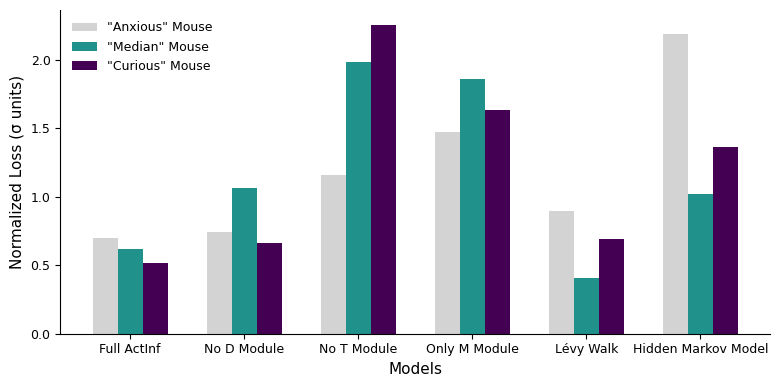

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# -------------------------
# Replace with your data
# -------------------------
models = ["Full ActInf", "Lévy Walk", "Hidden Markov Model"]
test_cases = ['"Median" Mouse', '"Anxious" Mouse', '"Curious" Mouse']

# Shape: (n_models, n_test_cases)
base_loss_values = np.array([
    [2.87, 3.66, 2.03],
    [1.24, 6.04, 3.59],
    [7.87, 35.94, 14.02],
])

std_loss_values = []
bic_loss_values = []

models = ["Full ActInf", "No D Module", "No T Module", "Only M Module", "Lévy Walk", "Hidden Markov Model"]

# Shape: (n_models, n_test_cases)
base_loss_values = np.array([
    [2.87, 3.66, 2.03],
    [8.47, 4.17, 3.28],
    [29.64, 10.07, 38.05],
    [25.88, 16.22, 20.11],
    [1.24, 6.04, 3.59],
    [7.87, 35.94, 14.02],
])

std_loss_values[:] = np.sqrt(base_loss_values / 7.5)

ks = np.array([5, 3, 20])
ks = np.array([5, 3, 4, 3, 3, 20])


logN = np.log(8)
bic_loss_values[:] = base_loss_values + ks[:, None] * logN



loss_values = np.array(std_loss_values)
# loss_values = np.array(bic_loss_values)

# -------------------------
# Styling parameters
# -------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.size": 11,
    "svg.fonttype": "none",  # keep text editable in SVG
})

# -------------------------
# Plot setup
# -------------------------
n_models = len(models)
n_tests = len(test_cases)

x = np.arange(n_models)
bar_width = 0.22

fig, ax = plt.subplots(figsize=(8, 4))

# Colormap (viridis)
# colors = cm.viridis(np.linspace(0.2, 0.8, n_tests))
colors = ['lightgrey', '#21918c', '#440154']
# -------------------------
# Plot bars
# -------------------------
# for i in range(n_tests):
#     ax.bar(
#         x + i * bar_width,
#         loss_values[:, i],
#         width=bar_width,
#         label=test_cases[i],
#         color=colors[i],
#         edgecolor='none'
#     )


ax.bar(
    x + 0 * bar_width,
    loss_values[:, 1],
    width=bar_width,
    label=test_cases[1],
    color=colors[0],
    edgecolor='none'
)

ax.bar(
    x + 1 * bar_width,
    loss_values[:, 0],
    width=bar_width,
    label=test_cases[0],
    color=colors[1],
    edgecolor='none'
)

ax.bar(
    x + 2 * bar_width,
    loss_values[:, 2],
    width=bar_width,
    label=test_cases[2],
    color=colors[2],
    edgecolor='none'
)

# -------------------------
# Axis formatting
# -------------------------
ax.set_xlabel("Models")
ax.set_ylabel("Normalized Loss (σ units)")

ax.set_xticks(x + bar_width * (n_tests - 1) / 2)
ax.set_xticklabels(models)

# Light horizontal gridlines only
# ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.3)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=9)

# Layout
plt.tight_layout()

# -------------------------
# Export (SVG)
# -------------------------
output_path = "model_loss_comparison.svg"
plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight",  # prevents clipping
)

plt.show()

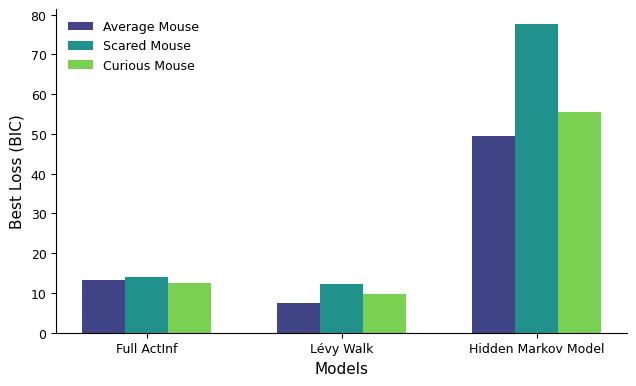

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# -------------------------
# Data
# -------------------------
models = ["Full ActInf", "Lévy Walk", "Hidden Markov Model"]

# Shape: (n_models, n_test_cases)
base_loss_values = np.array([
    [2.87, 3.66, 2.03],
    [1.24, 6.04, 3.59],
    [7.87, 35.94, 14.02],
])


# -------------------------
# BIC transformation
# -------------------------
ks = np.array([5, 3, 20])   # parameters per model
logN = np.log(8)

bic_loss_values = base_loss_values + ks[:, None] * logN

std_loss_values = np.sqrt(base_loss_values / 7.5)


loss_values = np.array(bic_loss_values)
# -------------------------
# Aggregate to one value per model
# -------------------------
# loss_per_model = std_loss_values.mean(axis=1)
# -------------------------
# Styling parameters
# -------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.size": 11,
    "svg.fonttype": "none",  # keep text editable in SVG
})

# -------------------------
# Plot setup
# -------------------------
n_models = len(models)
n_tests = len(test_cases)

x = np.arange(n_models)
bar_width = 0.22

fig, ax = plt.subplots(figsize=(6.5, 4))

# Colormap (viridis)
colors = cm.viridis(np.linspace(0.2, 0.8, n_tests))

# -------------------------
# Plot bars
# -------------------------
for i in range(n_tests):
    ax.bar(
        x + i * bar_width,
        loss_values[:, i],
        width=bar_width,
        label=test_cases[i],
        color=colors[i],
        edgecolor='none'
    )

# -------------------------
# Axis formatting
# -------------------------
ax.set_xlabel("Models")
ax.set_ylabel("Best Loss (BIC)")

ax.set_xticks(x + bar_width * (n_tests - 1) / 2)
ax.set_xticklabels(models)

# Light horizontal gridlines only
# ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.3)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()

# -------------------------
# Export (SVG)
# -------------------------
output_path = "alt_model_loss_bic.svg"
plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight",  # prevents clipping
)

plt.show()

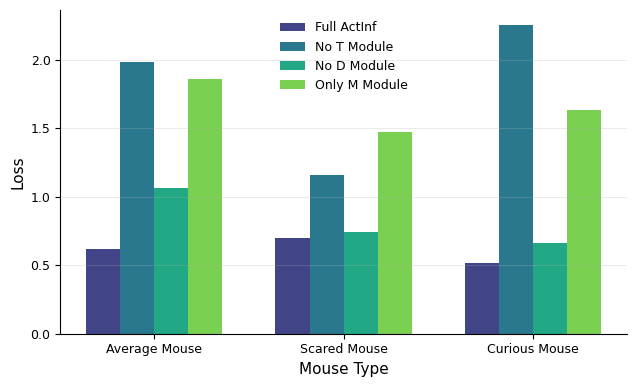

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

models = ["Full ActInf", "No T Module", "No D Module", "Only M Module"]
test_cases = ["Average Mouse", "Scared Mouse", "Curious Mouse"]

base_loss_values = np.array([
    [2.87, 3.66, 2.03],
    [29.64, 10.07, 38.05],
    [8.47, 4.17, 3.28],
    [25.88, 16.22, 20.11],
])

# --- compute transformed losses ---
std_loss_values = np.sqrt(base_loss_values / 7.5)

ks = np.array([5, 3, 4, 3])
logN = np.log(8)
bic_loss_values = base_loss_values + ks[:, None] * logN

loss_values = std_loss_values  # or bic_loss_values

# -------------------------
# Plot setup
# -------------------------
n_models = len(models)
n_tests = len(test_cases)

x = np.arange(n_tests)   # NOW test cases on x-axis
bar_width = 0.18

fig, ax = plt.subplots(figsize=(6.5, 4))

# Colors now correspond to models
colors = cm.viridis(np.linspace(0.2, 0.8, n_models))

# -------------------------
# Plot bars (loop over models)
# -------------------------
for i in range(n_models):
    ax.bar(
        x + i * bar_width,
        loss_values[i, :],   # <-- row per model
        width=bar_width,
        label=models[i],
        color=colors[i],
        edgecolor='none'
    )

# -------------------------
# Axis formatting
# -------------------------
ax.set_xlabel("Mouse Type")
ax.set_ylabel("Loss")

ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels(test_cases)

ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.3)
ax.xaxis.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np

final_mask = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
])


active_cells = np.argwhere(final_mask == 1) 
# Create a dictionary to map (row, col) to a zero-indexed bin ID (0-56)
bin_id_map = {tuple(pos): i for i, pos in enumerate(active_cells)}

def get_closest_bin(r, c):
    if final_mask[r, c] == 1:
        return bin_id_map[(r, c)]
    
    # Calculate Euclidean distance to all active cells
    distances = np.sum((active_cells - np.array([r, c]))**2, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_r, nearest_c = active_cells[nearest_idx]
    
    return bin_id_map[(nearest_r, nearest_c)]

def map_position(row, min_x, min_y, max_x, max_y, n_rows=5, n_cols=15, flipped=False):
    # Normalize and find raw grid coordinates
    x_norm = np.clip((row['Center_x'] - min_x) / (max_x - min_x), 0, 0.999)
    y_norm = np.clip((row['Center_y'] - min_y) / (max_y - min_y), 0, 0.999)

    if flipped:
        x_norm = 0.999 - x_norm
        y_norm = 0.999 - y_norm
    
    r = int(np.floor(y_norm * n_rows))
    c = int(np.floor(x_norm * n_cols))
    
    # Return the mapped bin ID using nearest-neighbor logic
    return get_closest_bin(r, c)

def get_trajectory(df, n_steps=2000, flipped=False):
    df_filtered = df.copy()
    # Coarse-grain into 2000 steps
    df_filtered['step_number'] = np.linspace(0, n_steps, len(df_filtered), endpoint=False).astype(int)
    # Aggregate mean position per step
    coarse_data = df_filtered.groupby('step_number').agg({
        'Center_x': 'mean',
        'Center_y': 'mean'
    }).reset_index()

    min_x, max_x = df_filtered['Center_x'].min(), df_filtered['Center_x'].max()
    min_y, max_y = df_filtered['Center_y'].min(), df_filtered['Center_y'].max()

    coarse_data['location'] = coarse_data.apply(map_position, axis=1, args=(min_x, min_y, max_x, max_y), flipped=flipped)
    final_table = coarse_data[['step_number', 'location']]

    return final_table


confidence_threshold = 0.8

df_16_pre = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_hab3_cropped.csv', index_col=0)
df_16_pre = df_16_pre[df_16_pre['Center_p'] > confidence_threshold]
trajectory_16_pre = get_trajectory(df_16_pre, n_steps=2000)['location']

df_16_post = pd.read_csv(f'./dlc/DLC_all_batches/m16_investigation_def2_cropped.csv', index_col=0)
df_16_post = df_16_post[df_16_post['Center_p'] > confidence_threshold]
trajectory_16_post = get_trajectory(df_16_post, n_steps=2000)['location']

trajectory_16_pre = trajectory_16_pre.to_list()
trajectory_16_post = trajectory_16_post.to_list()

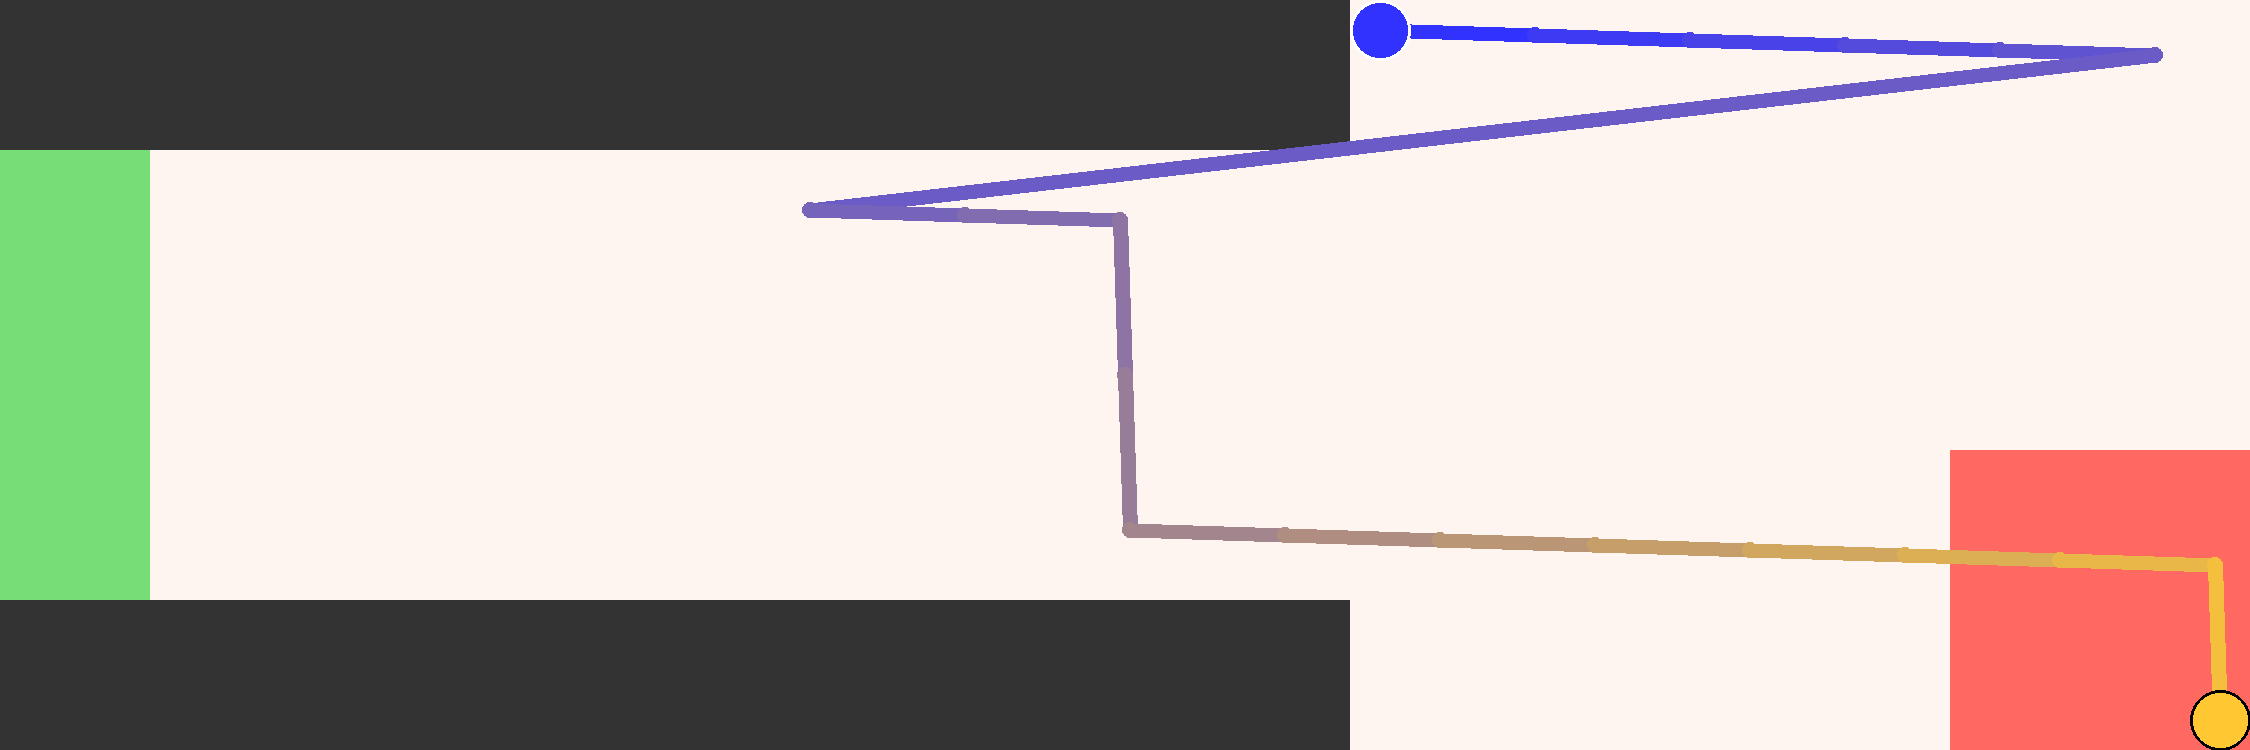

In [3]:
import numpy as np
from PIL import Image, ImageDraw

# --- Setup ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150 
rows, cols = mask.shape

# Visual Settings
line_width = int(cell_size * 0.10) 
marker_radius = int(cell_size * 0.2)

# MAX_OFFSET: How far from the center can the line drift?
# 0.3 means it uses the middle 60% of the cell, leaving 20% buffer on edges
max_offset = cell_size * 0.3  

colors = {
    'wall':    (51, 51, 51),
    'floor':   (255, 245, 240),
    'shelter': (119, 221, 119),
    'threat':  (255, 105, 97),
    'start':   (50, 50, 255),
    'end':     (255, 200, 50)
}

idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = [
    0, 1, 2, 3, 4, 5,              
    11, 12, 13, 28, 43, 44,        
    45, 46, 47, 48, 49, 50, 56     
]

def get_gradient_color(progress, start_rgb, end_rgb):
    r = int(start_rgb[0] + (end_rgb[0] - start_rgb[0]) * progress)
    g = int(start_rgb[1] + (end_rgb[1] - start_rgb[1]) * progress)
    b = int(start_rgb[2] + (end_rgb[2] - start_rgb[2]) * progress)
    return (r, g, b)

def draw_trace(traj):
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
    draw = ImageDraw.Draw(img)

    # 1. Draw Background
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                fill = colors['wall']
            elif c == 0 and 1 <= r <= 3:
                fill = colors['shelter']
            elif c >= 13 and r >= 3:
                fill = colors['threat']
            else:
                fill = colors['floor']
            
            draw.rectangle([x0, y0, x1, y1], fill=fill)

    if len(traj) > 1:
        points = []
        total_steps = len(traj)

        # 2. Calculate Points with TIME OFFSET
        for i, idx in enumerate(traj):
            r, c = idx_to_rc[idx]
            
            # Standard Center
            cx = c * cell_size + cell_size // 2
            cy = r * cell_size + cell_size // 2

            # Calculate Time Factor (0.0 at start, 1.0 at end)
            time_factor = i / max(1, total_steps - 1) 

            # Calculate Offset
            # If time_factor is 0 (start), offset is -max_offset (Top-Left)
            # If time_factor is 1 (end), offset is +max_offset (Bottom-Right)
            current_offset = -max_offset + (2 * max_offset * time_factor)

            # Apply offset to both X and Y to create a diagonal slide
            px = cx + current_offset
            py = cy + current_offset
            
            points.append((px, py))

        # 3. Draw Lines
        num_segments = len(points) - 1
        for i in range(num_segments):
            progress = i / max(1, num_segments)
            color = get_gradient_color(progress, colors['start'], colors['end'])
            
            p1 = points[i]
            p2 = points[i+1]

            draw.line([p1, p2], fill=color, width=line_width)
            
            # Draw joint to make corners smooth
            draw.ellipse([p1[0]-line_width/2, p1[1]-line_width/2, 
                          p1[0]+line_width/2, p1[1]+line_width/2], fill=color)

        # 4. Draw Start/End Markers (Using the offset positions)
        start_pt = points[0]
        end_pt = points[-1]
        
        # Start (Blue)
        draw.ellipse([start_pt[0]-marker_radius, start_pt[1]-marker_radius, 
                      start_pt[0]+marker_radius, start_pt[1]+marker_radius], 
                      fill=colors['start'], outline=(255,255,255), width=3)
        
        # End (Yellow)
        draw.ellipse([end_pt[0]-marker_radius, end_pt[1]-marker_radius, 
                      end_pt[0]+marker_radius, end_pt[1]+marker_radius], 
                      fill=colors['end'], outline=(0,0,0), width=3)
        
    return img

img = draw_trace(example_trajectory)
display(img)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


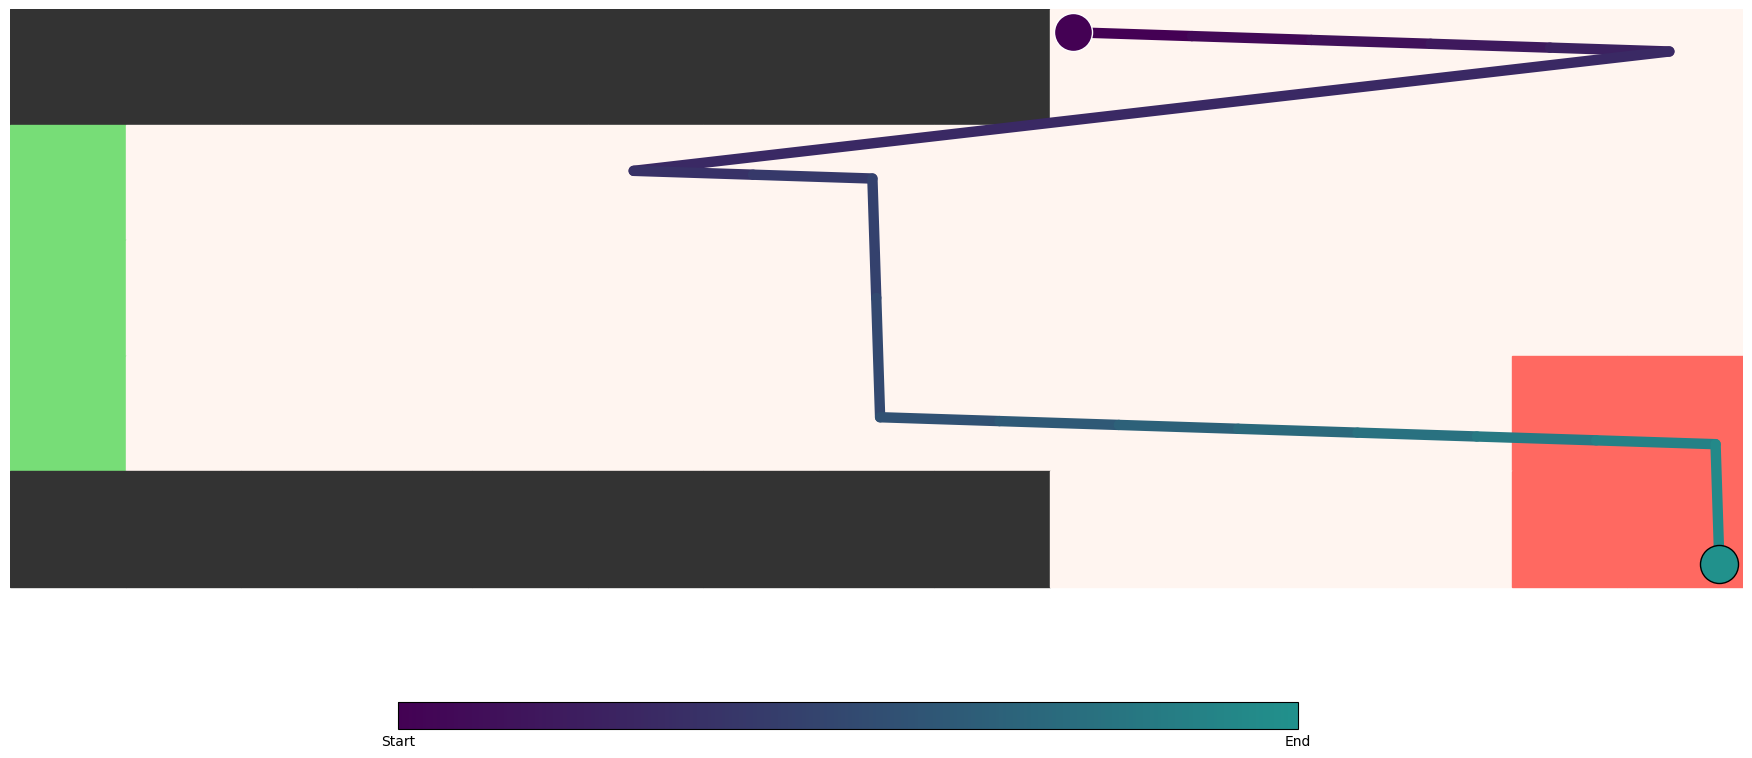

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# --- Setup ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150 
rows, cols = mask.shape
px_to_unit = 1/100 # Scaling for matplotlib

colors_svg = {
    'wall':    (51/255, 51/255, 51/255),
    'floor':   (255/255, 245/255, 240/255),
    'shelter': (119/255, 221/255, 119/255),
    'threat':  (255/255, 105/255, 97/255),
    'start':   (68/255, 1/255, 84/255),
    'end':     (33/255, 145/255, 140/255)
}

idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = [0, 1, 2, 3, 4, 5, 11, 12, 13, 28, 43, 44, 45, 46, 47, 48, 49, 50, 56]

def draw_trace_svg(traj, filename=None):
    # Create Figure
    fig, ax = plt.subplots(figsize=(cols * cell_size * px_to_unit, (rows+1) * cell_size * px_to_unit))
    ax.set_xlim(0, cols * cell_size)
    ax.set_ylim(0, (rows + 1) * cell_size) # Extra space for legend
    ax.set_aspect('equal')
    ax.axis('off')

    # 1. Draw Background
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, (rows - 1 - r + 1) * cell_size # Flip Y for matplotlib
            
            if not mask[r, c]:
                fill = colors_svg['wall']
            elif c == 0 and 1 <= r <= 3:
                fill = colors_svg['shelter']
            elif c >= 13 and r >= 3:
                fill = colors_svg['threat']
            else:
                fill = colors_svg['floor']
            
            ax.add_patch(patches.Rectangle((x0, y0), cell_size, cell_size, color=fill, zorder=1))

    # 2. Draw Trajectory
    if len(traj) > 1:
        max_offset = cell_size * 0.3
        points = []
        for i, idx in enumerate(traj):
            r, c = idx_to_rc[idx]
            cx = c * cell_size + cell_size / 2
            cy = (rows - 1 - r + 1) * cell_size + cell_size / 2
            time_factor = i / max(1, len(traj) - 1)
            current_offset = -max_offset + (2 * max_offset * time_factor)
            points.append((cx + current_offset, cy - current_offset))

        # Gradient Line
        for i in range(len(points) - 1):
            progress = i / (len(points) - 1)
            c = [(1-progress)*colors_svg['start'][j] + progress*colors_svg['end'][j] for j in range(3)]
            ax.plot([points[i][0], points[i+1][0]], [points[i][1], points[i+1][1]], 
                    color=c, linewidth=cell_size*0.05, solid_capstyle='round', zorder=3)

        # Start/End Markers
        ax.scatter(*points[0], color=colors_svg['start'], s=750, edgecolors='white', zorder=4)
        ax.scatter(*points[-1], color=colors_svg['end'], s=750, edgecolors='black', zorder=4)

    # 3. ADD LEGEND BAR (Blue to Yellow)
    # Positioning the bar at the bottom center
    gradient_ax = fig.add_axes([0.3, 0.08, 0.4, 0.03]) # [left, bottom, width, height]
    cmap = LinearSegmentedColormap.from_list('custom_grad', [colors_svg['start'], colors_svg['end']])
    cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=gradient_ax, orientation='horizontal')
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['Start', 'End'])
    gradient_ax.tick_params(labelsize=10, length=0)

    # 4. SAVE AS SVG
    if filename is not None:
        plt.savefig(filename, format='svg', bbox_inches='tight', transparent=True)
    plt.show()

draw_trace_svg(example_trajectory, filename=None)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


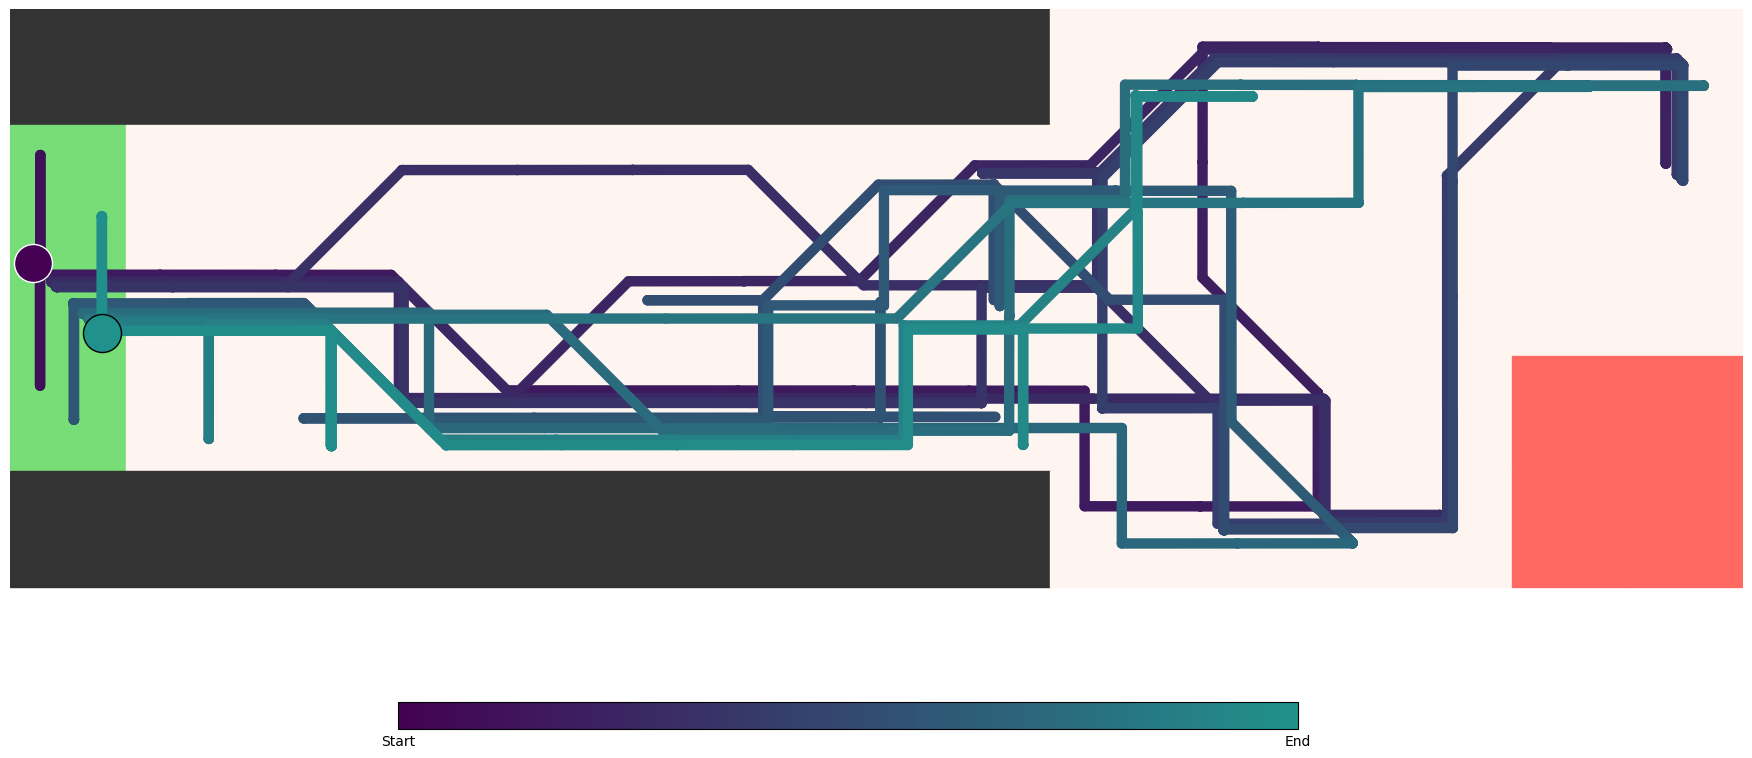

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


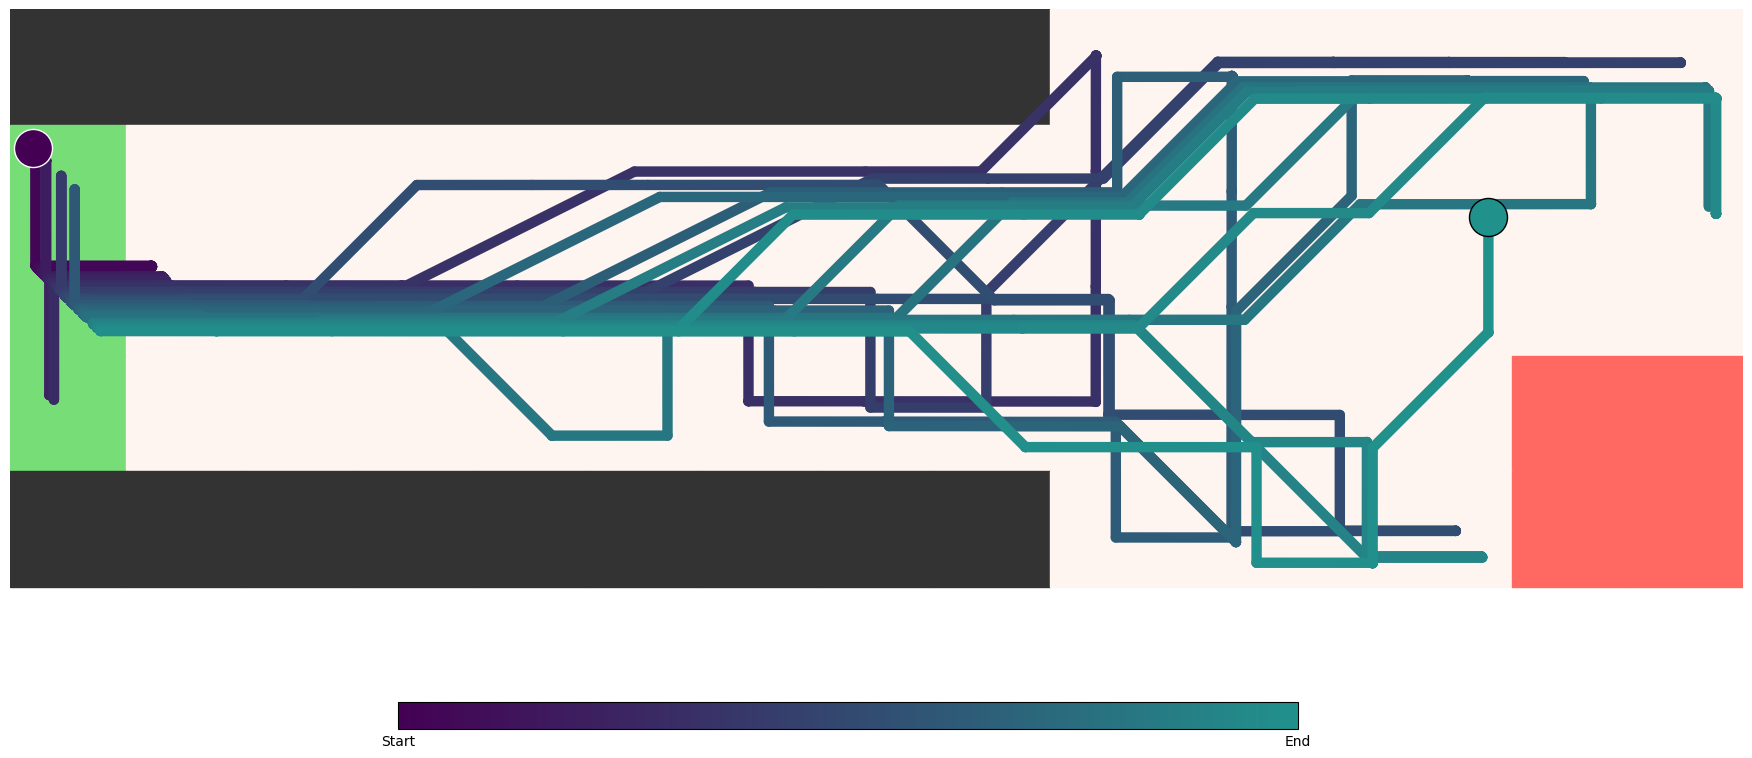

pre


None

post


None

In [5]:
trace_16_pre = draw_trace_svg(trajectory_16_pre)
trace_16_post = draw_trace_svg(trajectory_16_post)
print("pre")
display(trace_16_pre)
print("post")
display(trace_16_post)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


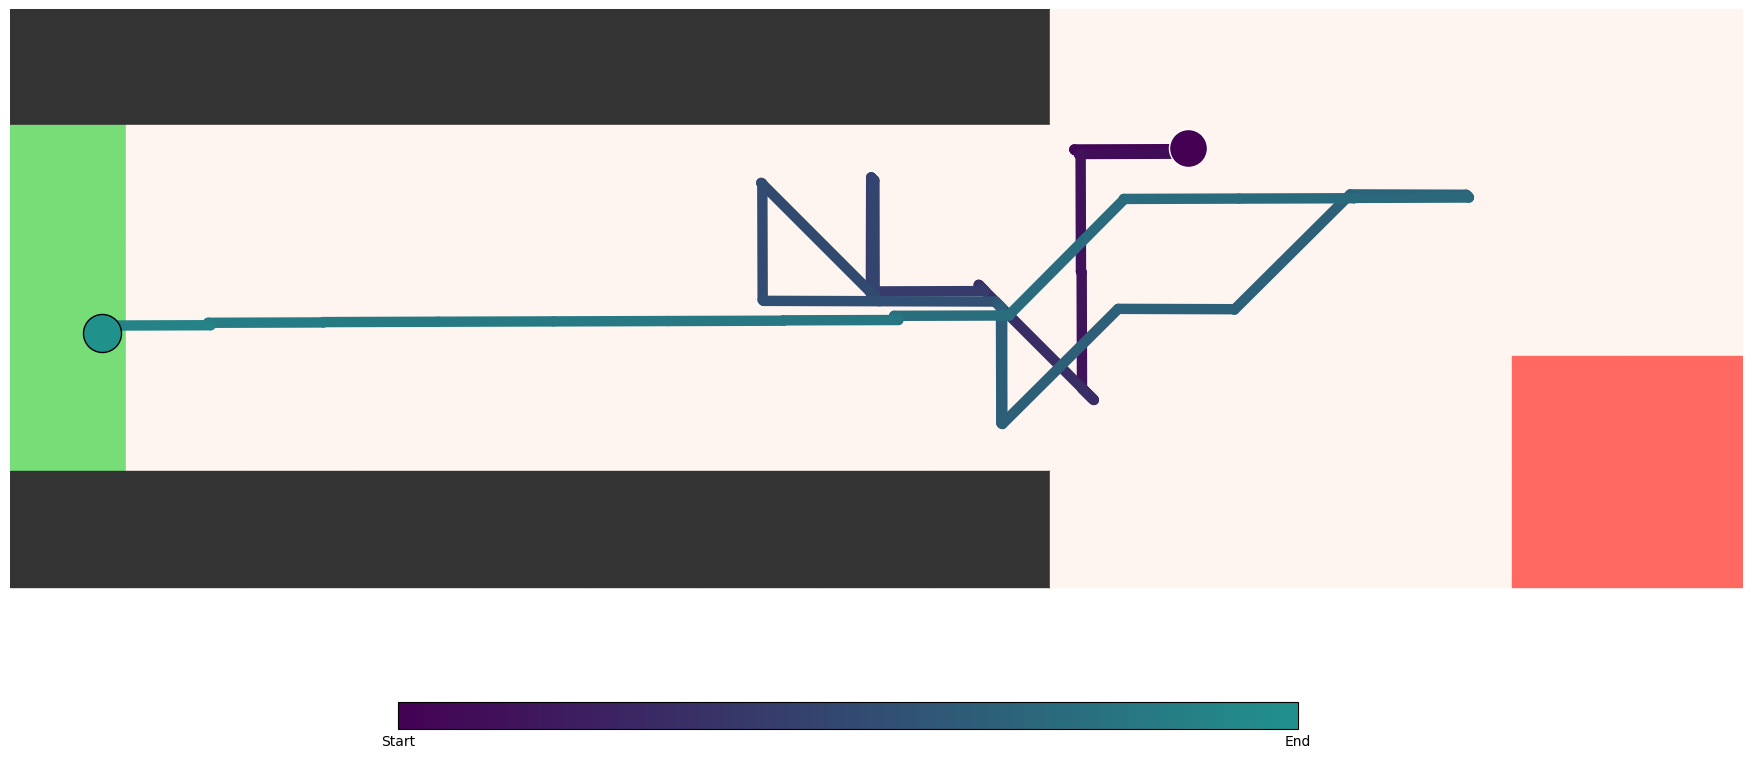

None

In [6]:
df_22_pre = pd.read_csv(f'./dlc/DLC_all_batches/m22_investigation_def1_cropped.csv', index_col=0)
df_22_pre = df_22_pre[df_22_pre['Center_p'] > confidence_threshold]
trajectory_explorer = get_trajectory(df_22_pre, n_steps=2000, flipped=True)['location'].to_list()

# start_step = 1500
# n_steps = 2000
# trace_26_post = draw_trace(trajectory_26_post[start_step:n_steps])
# display(trace_26_post) # SCARED MOUSE

start_step = 0
n_steps = 2000
trace_explorer = draw_trace_svg(trajectory_explorer[1800:2000])
display(trace_explorer) # EXPLORER

In [ ]:
df_22_pre = pd.read_csv(f'./dlc/DLC_all_batches/m26_investigation_def3_cropped.csv', index_col=0)
df_22_pre = df_22_pre[df_22_pre['Center_p'] > confidence_threshold]
trajectory_explorer = get_trajectory(df_22_pre, n_steps=2000, flipped=True)['location'].to_list()

# start_step = 1500
# n_steps = 2000
# trace_26_post = draw_trace(trajectory_26_post[start_step:n_steps])
# display(trace_26_post) # SCARED MOUSE

start_step = 0
n_steps = 2000
trace_explorer = draw_trace_svg(trajectory_explorer, 'trace_scared_real.svg')
display(trace_explorer) # EXPLORER

In [ ]:
df_explorer_model = pd.read_csv(f'./Control_history/trial_62.csv')
# df_explorer_model = df_explorer_model['location']

# traj_exp_model = df_explorer_model['location'].tolist()
# traj_exp_model
traj_model_exp = df_explorer_model['location'].tolist()

trace_explorer_model = draw_trace_svg(traj_model_exp, 'trace_explorer_model.svg')

In [ ]:
import pandas as pd
df_sc_model = pd.read_csv(f'./Resilient_def_history/trial_26.csv')
# df_explorer_model = df_explorer_model['location']

# traj_exp_model = df_explorer_model['location'].tolist()
# traj_exp_model
traj_model_sc = df_sc_model['location'].tolist()

trace_scared_model = draw_trace_svg(traj_model_sc[755:800], 'trace_fl1_model.svg')
# print(len(traj_model_sc))

In [ ]:
from collections import Counter
import matplotlib.cm as cm
import math
from PIL import ImageFont

c_wall = []
for i in colors_svg['wall']:
    c_wall.append(int(i*255))

c_wall = tuple(c_wall)

def draw_difference_heatmap(traj_a, traj_b, opacity=0.85):
    # 1. Calculate Differences (B - A)
    counts_a = Counter(traj_a)
    counts_b = Counter(traj_b)
    
    # Get set of all visited locations in either trajectory
    all_indices = set(counts_a.keys()).union(set(counts_b.keys()))
    
    diff_map = {}
    max_diff = 1 # Avoid div by zero
    
    for idx in all_indices:
        # Post (b) - Pre (a)
        val = counts_b.get(idx, 0) - counts_a.get(idx, 0)
        diff_map[idx_to_rc[idx]] = val
        if abs(val) > max_diff:
            max_diff = abs(val)

    # 2. Setup Image
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    
    # Use a diverging colormap: Blue (neg) <-> White (0) <-> Red (pos)
    colormap = cm.get_cmap('bwr') 
    
    # Font for overlay numbers
    try:
        fnt = ImageFont.truetype("arial.ttf", 40)
    except:
        fnt = ImageFont.load_default()

    # 3. Draw Grid
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                # Wall
                draw.rectangle([x0, y0, x1, y1], fill=c_wall)
            else:
                diff = diff_map.get((r, c), 0)
                
                # Normalize difference to 0.0 - 1.0 range for the colormap
                # 0.0 = Max Negative (Blue)
                # 0.5 = Zero Change (White)
                # 1.0 = Max Positive (Red)
                norm_val = 0.5 + 0.5 * (diff / max_diff)
                
                rgba_float = colormap(norm_val)
                r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
                
                # Draw Cell
                draw.rectangle([x0, y0, x1, y1], fill=(r_val, g_val, b_val))
                
                # 4. Optional: Text Overlay (The "Sharpening" trick)
                # Only draw text if the difference is significant enough to care
                if abs(diff) > 0:
                    msg = f"{diff:+}" # Adds + sign for positives
                    
                    # Calculate text size to center it
                    bbox = draw.textbbox((0, 0), msg, font=fnt)
                    w = bbox[2] - bbox[0]
                    h = bbox[3] - bbox[1]
                    
                    # Contrast text color: Black for light backgrounds, White for dark
                    # (Simple heuristic: if val is extreme, use white text)
                    text_col = (0,0,0) if 0.3 < norm_val < 0.7 else (255,255,255)
                    
                    draw.text((x0 + (cell_size-w)/2, y0 + (cell_size-h)/2), msg, fill=text_col, font=fnt)

    return img

In [ ]:
from scipy.ndimage import gaussian_filter

def draw_heatmap_smoothed(traj, saturation_threshold=0.2, cmap='viridis', max_visits=None, smoothing_sigma=0.0):
    # --- 1. Create Data Grid ---
    visit_counts = Counter(traj)
    
    # Initialize a 2D numpy array for the grid
    # We use floats to allow for the partial values from smoothing
    grid_data = np.zeros((rows, cols), dtype=float)
    
    # Fill the grid with raw counts
    for idx, count in visit_counts.items():
        r, c = idx_to_rc[idx]
        grid_data[r, c] = count
        
    # --- 2. Apply Spatial Smoothing (The New Step) ---
    if smoothing_sigma > 0:
        # We apply a Gaussian filter to the grid data itself.
        # This spreads the "heat" to neighboring cells mathematically.
        grid_data = gaussian_filter(grid_data, sigma=smoothing_sigma, mode='constant', cval=0)
        
        # KEY STEP: Masking
        # Smoothing might spread values into the walls (which are 0 in the mask).
        # We must re-zero the walls so they don't glow.
        # mask is boolean: True=Floor, False=Wall. 
        # (Assuming your mask is 1 for floor, 0 for wall as per your first snippet)
        grid_data = grid_data * mask

    zero_coords = [(3, 13), (3, 14), (4, 13), (4, 14)] 
    for r, c in zero_coords:
        if 0 <= r < rows and 0 <= c < cols:
            grid_data[r, c] = 0

    # --- 3. Normalization Setup ---
    # We need to recalculate max because smoothing spreads the peaks, lowering the max value.
    if max_visits is None:
        current_max = np.max(grid_data)
    else:
        # If the user provided a raw count max (e.g. 2000), we need to respect that,
        # but technically smoothing lowers peaks. For visualization consistency,
        # we usually just use the max of the current smoothed data or a fixed visual scale.
        current_max = max_visits 

    # Recalculate scale based on the (potentially smoothed) data peaks
    scale_max = current_max * saturation_threshold
    scale_max = max(scale_max, 1) # avoid div zero
    log_denominator = math.log(scale_max + 1)
    
    # --- 4. Drawing ---
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            if not mask[r, c]:
                # Wall
                draw.rectangle([x0, y0, x1, y1], fill=c_wall, outline=None)
            else:
                # Floor
                val = grid_data[r, c]
                clamped_val = min(val, scale_max)
                
                # Log Transform
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba_float = colormap(intensity)
                r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
                
                draw.rectangle([x0, y0, x1, y1], fill=(r_val, g_val, b_val), outline=None)

    # --- 4. Draw Legend (Using final_map_img height) ---
    legend_width = 150
    final_map_img = img
    bar_width = 40
    padding = 40
    legend_img = Image.new('RGB', (legend_width, final_map_img.height), (255, 255, 255))
    legend_draw = ImageDraw.Draw(legend_img)
    bar_height = final_map_img.height - (padding * 2)
    bar_x = 30
    bar_y_start = padding

    for y in range(bar_height):
        progress = 1.0 - (y / bar_height)
        raw_count_at_pixel = progress * scale_max
        intensity = math.log(raw_count_at_pixel + 1) / log_denominator
        rgba = colormap(intensity)
        color = tuple(int(c * 255) for c in rgba[:3])
        legend_draw.line([(bar_x, bar_y_start + y), (bar_x + bar_width, bar_y_start + y)], fill=color)

    legend_draw.rectangle([bar_x, bar_y_start, bar_x + bar_width, bar_y_start + bar_height], outline=(0,0,0), width=2)

    try:
        font = ImageFont.truetype("arial.ttf", 30)
        font_sm = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
        font_sm = ImageFont.load_default()

    text_x = bar_x + bar_width + 15
    legend_draw.text((text_x, bar_y_start - 10), f">={scale_max}", fill=(0,0,0), font=font)
    mid_y = bar_y_start + (bar_height // 2)
    mid_val = int(scale_max / 2)
    legend_draw.text((text_x, mid_y - 10), f"{mid_val}", fill=(0,0,0), font=font)
    legend_draw.text((text_x, bar_y_start + bar_height - 20), "0", fill=(0,0,0), font=font)
    legend_draw.text((text_x, bar_y_start + bar_height + 15), "Visits", fill=(100,100,100), font=font_sm)

    # --- 5. Composite Final Image ---
    final_w = final_map_img.width + legend_img.width
    final_h = final_map_img.height
    final_composite = Image.new('RGB', (final_w, final_h))
    final_composite.paste(final_map_img, (0, 0))
    final_composite.paste(legend_img, (final_map_img.width, 0))

    return final_composite

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import math
from collections import Counter
from scipy.ndimage import gaussian_filter

def draw_heatmap_matplotlib(traj, rows, cols, cell_size, mask, idx_to_rc, c_wall, 
                             saturation_threshold=0.2, cmap='viridis', 
                             max_visits=None, smoothing_sigma=0.0):
    # --- 1. Create Data Grid ---
    visit_counts = Counter(traj)
    grid_data = np.zeros((rows, cols), dtype=float)
    
    for idx, count in visit_counts.items():
        r, c = idx_to_rc.get(idx, (0,0))
        grid_data[r, c] = count
        
    # --- 2. Apply Spatial Smoothing ---
    if smoothing_sigma > 0:
        grid_data = gaussian_filter(grid_data, sigma=smoothing_sigma, mode='constant', cval=0)
        grid_data = grid_data * mask

    # --- 3. Forced Zero-Out Step ---
    zero_coords = [(3, 13), (3, 14), (4, 13), (4, 14)] 
    for r, c in zero_coords:
        if 0 <= r < rows and 0 <= c < cols:
            grid_data[r, c] = 0

    # --- 4. Normalization Setup ---
    current_max = max_visits if max_visits is not None else np.max(grid_data)
    scale_max = max(current_max * saturation_threshold, 1)
    
    # --- 5. Plotting ---
    wall_color = np.array(c_wall) / 255.0 if isinstance(c_wall, tuple) else c_wall

    # Create figure - figsize now controls the overall canvas
    fig, ax_map = plt.subplots(figsize=(10, 8))
    
    masked_data = np.ma.masked_where(mask == 0, grid_data)
    current_cmap = cm.get_cmap(cmap).copy()
    current_cmap.set_bad(color=wall_color)

    class CustomLogNorm(mcolors.Normalize):
        def __call__(self, value, clip=None):
            v_clipped = np.clip(value, 0, scale_max)
            return np.log1p(v_clipped) / np.log1p(scale_max)

    img = ax_map.imshow(masked_data, cmap=current_cmap, norm=CustomLogNorm(), 
                        origin='upper', aspect='equal')
    
    ax_map.axis('off') 

    # --- 6. Fixed-Size Legend (Colorbar) ---
    # This creates an axis divider to append a colorbar that is exactly 5% 
    # of the map width and has a fixed padding.
    divider = make_axes_locatable(ax_map)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    
    cb = fig.colorbar(img, cax=cax, orientation='vertical')
    
    # Labeling
    cb.set_ticks([0, 0.5, 1.0]) 
    cb.set_ticklabels(['0', f'{int(scale_max/2)}', f'>={int(scale_max)}'])
    
    cax.set_ylabel('Visits', color=(0.4, 0.4, 0.4), fontsize=10, labelpad=10)
    cax.yaxis.set_label_position('right')

    return fig

In [ ]:
# max_v = max(max(Counter(trajectory_16_pre).values()), max(Counter(trajectory_16_post).values()))
counts_pre = list(Counter(trajectory_16_pre).values())
counts_post = list(Counter(trajectory_16_post).values())
all_counts = counts_pre + counts_post


data_driven_max = int(np.percentile(all_counts, 95)) 


max_v = data_driven_max
# max_v = 2000
thres = 1

sigma = 0.7
heatmap_16_pre1 = draw_heatmap_smoothed(trajectory_16_pre, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)
# heatmap_16_post1 = draw_heatmap_smoothed(trajectory_16_post, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)

heatmap_svg1 = draw_heatmap_matplotlib(trajectory_16_pre, rows, cols, 250, mask, idx_to_rc, c_wall, saturation_threshold = thres, max_visits=None, smoothing_sigma=sigma)
# diff_image = draw_difference_heatmap(trajectory_16_pre, trajectory_16_post)
# draw_heatmap_matplotlib(rows: Any, cols: Any, cell_size: Any, mask: Any, idx_to_rc: Any, c_wall: Any, saturation_threshold: float = 0.2, cmap: str = 'viridis', max_visits: Any)
# display(diff_image)

display(heatmap_16_pre1)
plt.show(heatmap_svg1)

In [ ]:
import numpy as np
import math
import matplotlib.cm as cm
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
from scipy.ndimage import gaussian_filter

# --- Helper: Convert Trajectory to Smoothed Grid ---
def get_smoothed_density(traj, rows, cols, mask, idx_to_rc, sigma=1.0):
    # 1. Create empty grid
    grid = np.zeros((rows, cols), dtype=float)
    
    # 2. Fill with raw counts
    counts = Counter(traj)
    for idx, count in counts.items():
        r, c = idx_to_rc[idx]
        grid[r, c] = count

    # 3. Apply Gaussian Smoothing (The "Spread")
    if sigma > 0:
        grid = gaussian_filter(grid, sigma=sigma, mode='constant', cval=0)
        
    # 4. Re-apply Mask (Zero out walls so they don't glow)
    # Assumes mask is 1 for floor, 0 for wall
    grid = grid * mask 
    
    return grid

# --- Main Drawing Function ---
def draw_density_map(grid_data, max_val, cell_size=150, cmap='viridis'):
    rows, cols = grid_data.shape
    
    # 1. Setup Scaling
    # We use the provided max_val (calculated externally) for the color scale
    scale_max = max(max_val, 1e-5) # avoid div zero
    log_denominator = math.log(scale_max + 1)
    
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), (51, 51, 51)) # c_wall
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    # 2. Draw Grid
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            # Check mask (if value is 0 and it's a wall, keep it wall color)
            # We use the grid value itself to determine floor/wall loosely, 
            # or rely on the global mask variable if available.
            if mask[r,c] == 0:
                draw.rectangle([x0, y0, x1, y1], fill=(51,51,51))
            else:
                val = grid_data[r, c]
                # Clamp to max
                clamped_val = min(val, scale_max)
                
                # Log Transform
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba = colormap(intensity)
                color = tuple(int(x*255) for x in rgba[:3])
                
                draw.rectangle([x0, y0, x1, y1], fill=color)

    # 3. Draw Legend (Simplified for Density)
    legend_width = 150
    legend = Image.new('RGB', (legend_width, img.height), (255,255,255))
    l_draw = ImageDraw.Draw(legend)
    
    # Draw Gradient Bar
    bar_x, bar_w, pad = 30, 40, 40
    bar_h = img.height - (pad * 2)
    
    for y in range(bar_h):
        prog = 1 - (y/bar_h)
        val = prog * scale_max
        intensity = math.log(val + 1) / log_denominator
        c = tuple(int(x*255) for x in colormap(intensity)[:3])
        l_draw.line([(bar_x, pad+y), (bar_x+bar_w, pad+y)], fill=c)
        
    l_draw.rectangle([bar_x, pad, bar_x+bar_w, pad+bar_h], outline=(0,0,0), width=2)
    
    # Labels
    try: font = ImageFont.truetype("Inter.ttf", 9)
    except: font = ImageFont.load_default()
    
    # Since we smoothed, these aren't exact visit counts anymore, 
    # they are "Density" or "Activity" levels.
    l_draw.text((bar_x+bar_w+10, pad-10), f"High", fill=(0,0,0), font=font)
    l_draw.text((bar_x+bar_w+10, pad+bar_h-20), "Low", fill=(0,0,0), font=font)

    # Composite
    final = Image.new('RGB', (img.width + legend_width, img.height))
    final.paste(img, (0,0))
    final.paste(legend, (img.width, 0))
    
    return final

# --- EXECUTION: The Combined Method ---

# 1. Generate Smoothed Data Grids FIRST
# Sigma 0.8 is a sweet spot: clearly connects areas, but keeps shapes distinct
SIGMA = 1.0

grid_pre = get_smoothed_density(trajectory_16_pre, rows, cols, mask, idx_to_rc, sigma=SIGMA)
grid_post = get_smoothed_density(trajectory_16_post, rows, cols, mask, idx_to_rc, sigma=SIGMA)

# 2. Calculate Shared 95th Percentile
# We pool all active floor pixels from both maps to find the common "Max"
valid_pixels = np.concatenate([
    grid_pre[mask],  # Select only floor pixels
    grid_post[mask]
])

if len(valid_pixels) > 0:
    shared_max = np.percentile(valid_pixels, 95) # The "Bright Yellow" Threshold
else:
    shared_max = 1.0

# 3. Draw Both using the Shared Max
map_pre = draw_density_map(grid_pre, shared_max, cmap='viridis')
map_post = draw_density_map(grid_post, shared_max, cmap='viridis')

map_pre.save("heatmap_pre.png")
map_post.save("heatmap_post.png")
display(map_pre)
display(map_post)

In [ ]:
import numpy as np
import math
import matplotlib.cm as cm
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
from scipy.ndimage import gaussian_filter

# --- 1. Define the Environment ---

# ORIGINAL MASK: Used to map your data indices correctly
# (Do not change this if your data indices depend on it)
data_mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# RENDER MASK: The visual mask where we force the bottom-right to be walls.
render_mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,0,0]
], dtype=bool)



cell_size = 150
rows, cols = data_mask.shape
c_wall = (51, 51, 51)

# Map indices to (row, col) using the DATA mask
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if data_mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

# --- 2. Advanced Smoothing Function (Normalized) ---
def get_smoothed_density_normalized(traj, rows, cols, mask, idx_to_rc, sigma=1.0):
    """
    Calculates density while accounting for walls.
    'mask' determines which cells are valid for spreading heat.
    """
    # Initialize grid
    grid = np.zeros((rows, cols), dtype=float)
    counts = Counter(traj)
    
    # Fill grid (Only if the index maps to a valid location)
    for idx, count in counts.items():
        if idx in idx_to_rc:
            r, c = idx_to_rc[idx]
            # If our render_mask says this is now a wall, we ignore the visits here
            if mask[r, c]: 
                grid[r, c] = count

    if sigma > 0:
        # A. Smooth the Data
        smoothed_data = gaussian_filter(grid, sigma=sigma, mode='constant', cval=0)
        
        # B. Smooth the Mask (Calculates available floor area)
        # This prevents edge-darkening (vignetting) near walls
        smoothed_weights = gaussian_filter(mask.astype(float), sigma=sigma, mode='constant', cval=0)
        
        # C. Normalize
        with np.errstate(divide='ignore', invalid='ignore'):
            grid = smoothed_data / smoothed_weights
            grid[np.isnan(grid)] = 0
            
    # Final Crop: Ensure walls are strictly 0
    grid = grid * mask 
    return grid

# --- 3. Drawing Function ---
def draw_density_map(grid_data, max_val, mask, cell_size=150, cmap='viridis'):
    rows, cols = grid_data.shape
    scale_max = max(max_val, 1e-5)
    log_denominator = math.log(scale_max + 1)
    
    img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
    draw = ImageDraw.Draw(img)
    colormap = cm.get_cmap(cmap)
    
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            
            # If render_mask says it's a wall, draw dark gray
            if not mask[r, c]:
                draw.rectangle([x0, y0, x1, y1], fill=c_wall)
            else:
                val = grid_data[r, c]
                clamped_val = min(val, scale_max)
                intensity = math.log(clamped_val + 1) / log_denominator
                
                rgba = colormap(intensity)
                color = tuple(int(x*255) for x in rgba[:3])
                draw.rectangle([x0, y0, x1, y1], fill=color)

    # --- Draw Legend ---
    legend_width = 150
    legend = Image.new('RGB', (legend_width, img.height), (255,255,255))
    l_draw = ImageDraw.Draw(legend)
    
    bar_x, bar_w, pad = 30, 40, 40
    bar_h = img.height - (pad * 2)
    
    for y in range(bar_h):
        prog = 1 - (y/bar_h)
        val = prog * scale_max
        intensity = math.log(val + 1) / log_denominator
        c = tuple(int(x*255) for x in colormap(intensity)[:3])
        l_draw.line([(bar_x, pad+y), (bar_x+bar_w, pad+y)], fill=c)
        
    l_draw.rectangle([bar_x, pad, bar_x+bar_w, pad+bar_h], outline=(0,0,0), width=2)
    
    try: font = ImageFont.truetype("arial.ttf", 24)
    except: font = ImageFont.load_default()
    
    l_draw.text((bar_x+bar_w+10, pad-10), "High", fill=(0,0,0), font=font)
    l_draw.text((bar_x+bar_w+10, pad+bar_h-20), "Low", fill=(0,0,0), font=font)

    final = Image.new('RGB', (img.width + legend_width, img.height))
    final.paste(img, (0,0))
    final.paste(legend, (img.width, 0))
    
    return final

# --- 4. Execution ---

# A. Generate Smoothed Grids using RENDER_MASK
# Sigma 0.8 gives a clear "Region" look without losing detail
SIGMA = 1.0

grid_pre = get_smoothed_density_normalized(trajectory_16_pre, rows, cols, render_mask, idx_to_rc, sigma=SIGMA)
grid_post = get_smoothed_density_normalized(trajectory_16_post, rows, cols, render_mask, idx_to_rc, sigma=SIGMA)

# B. Calculate Shared 95th Percentile (Contrast Boost)
# We only look at pixels that are FLOOR in the RENDER mask
valid_pixels = np.concatenate([
    grid_pre[render_mask], 
    grid_post[render_mask]
])

if len(valid_pixels) > 0:
    shared_max = np.percentile(valid_pixels, 95)
else:
    shared_max = 1.0

# C. Draw
map_pre = draw_density_map(grid_pre, shared_max, render_mask, cmap='viridis')
map_post = draw_density_map(grid_post, shared_max, render_mask, cmap='viridis')

display(map_pre)
display(map_post)

In [ ]:
from matplotlib import font_manager as fm
import matplotlib as mpl

font_dir = "/mnt/c/Users/hridai/Downloads/Inter(1)/static"

fonts = [
    "Inter_18pt-Regular.ttf",
    "Inter_18pt-Italic.ttf",
    "Inter_18pt-SemiBold.ttf",
    "Inter_18pt-Bold.ttf",
    "Inter_18pt-BoldItalic.ttf",
]

for f in fonts:
    fm.fontManager.addfont(f"{font_dir}/{f}")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter"],
    "font.weight": "regular",
    "svg.fonttype": "none",
})


In [ ]:
import matplotlib.font_manager as fm
[(f.name, f.fname) for f in fm.fontManager.ttflist if "Inter" in f.name]


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import seaborn as sns
from scipy import stats
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"   # keep text as text
mpl.rcParams["text.usetex"] = False     # disable LaTeX text rendering
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter 18pt"],
    "svg.fonttype": "none",
})

# 1. Load Data
# data_str = """
# mouse_number    phase    t_shelter    t_investigating
# 13    pre-defeat    0.5015    0.126
# 13    post-defeat    0.2165    0.2755
# 14    pre-defeat    0.4895    0.104
# 14    post-defeat    0.3215    0.2595
# 15    pre-defeat    0.688    0.0825
# 15    post-defeat    0.354    0.1315
# 16    pre-defeat    0.1445    0.387
# 16    post-defeat    0.6055    0.1115
# 17    pre-defeat    0.4405    0.2235
# 17    post-defeat    0.426    0.2915
# 18    pre-defeat    0.4175    0.1405
# 18    post-defeat    0.317    0.206
# 19    pre-defeat    0.2555    0.211
# 19    post-defeat    0.5945    0.046
# 20    pre-defeat    0.1435    0.3655
# 20    post-defeat    0.1    0.391
# 21    pre-defeat    0.241    0.483
# 21    post-defeat    0.135    0.434
# 22    pre-defeat    0.2155    0.139
# 22    post-defeat    0.142    0.2575
# 23    pre-defeat    0.1945    0.3365
# 23    post-defeat    0.3255    0.3865
# 24    pre-defeat    0.09    0.559
# 24    post-defeat    0.6385    0.1175
# 25    pre-defeat    0.127    0.5135
# 25    post-defeat    0.127    0.517
# 26    pre-defeat    0.291    0.3945
# 26    post-defeat    0.824    0.057
# """

data_str = """
mouse_number    phase    t_shelter    t_investigating
13    pre-defeat    0.5015    0.126
13    post-defeat    0.2165    0.2755
14    pre-defeat    0.4895    0.104
14    post-defeat    0.3215    0.2595
15    pre-defeat    0.688    0.0825
15    post-defeat    0.354    0.1315
16    pre-defeat    0.1445    0.387
16    post-defeat    0.6055    0.1115
17    pre-defeat    0.4405    0.2235
17    post-defeat    0.426    0.2915
18    pre-defeat    0.4175    0.1405
18    post-defeat    0.317    0.206
20    pre-defeat    0.1435    0.3655
20    post-defeat    0.1    0.391
21    pre-defeat    0.241    0.483
21    post-defeat    0.135    0.434
22    pre-defeat    0.2155    0.139
22    post-defeat    0.142    0.2575
23    pre-defeat    0.1945    0.3365
23    post-defeat    0.3255    0.3865
24    pre-defeat    0.09    0.559
24    post-defeat    0.6385    0.1175
25    pre-defeat    0.127    0.5135
25    post-defeat    0.127    0.517
26    pre-defeat    0.291    0.3945
26    post-defeat    0.824    0.057
"""
from matplotlib.font_manager import FontProperties
FONT_DIR = "/mnt/c/Users/hridai/Downloads/Inter(1)/static"

fp_regular = FontProperties(
    fname=f"{FONT_DIR}/Inter_18pt-Regular.ttf"
)

fp_semibold = FontProperties(
    fname=f"{FONT_DIR}/Inter_18pt-SemiBold.ttf"
)

fp_bold = FontProperties(
    fname=f"{FONT_DIR}/Inter_18pt-Bold.ttf"
)

df = pd.read_csv(io.StringIO(data_str), sep='\s+')

# 2. Assign Groups
control_ids = [13, 15, 18, 20, 21, 22, 25]
defeat_ids = [14, 16, 17, 19, 23, 24, 26]
df['group'] = df['mouse_number'].apply(lambda x: 'Control' if x in control_ids else 'Defeat')

# 3. Calculate Deltas
pivot_df = df.pivot(index=['mouse_number', 'group'], columns='phase', values=['t_investigating', 't_shelter'])
delta_df = pd.DataFrame()
delta_df['delta_investigation'] = pivot_df[('t_investigating', 'post-defeat')] - pivot_df[('t_investigating', 'pre-defeat')]
delta_df['delta_shelter'] = pivot_df[('t_shelter', 'post-defeat')] - pivot_df[('t_shelter', 'pre-defeat')]
delta_df = delta_df.reset_index()

# 4. Statistical Function (One-Tailed Unpaired T-test)
def add_stat_annotation(ax, data, col, x1, x2, direction='greater'):
    """
    direction='greater' checks if Control > Defeat (e.g. Investigation where Defeat drops)
    direction='less' checks if Control < Defeat (e.g. Shelter where Defeat rises)
    """
    group_ctrl = data[data['group'] == 'Control'][col]
    group_def = data[data['group'] == 'Defeat'][col]
    
    # One-Tailed Unpaired T-test
    # We use 'alternative' to specify the hypothesis
    t_stat, p_val = stats.ttest_ind(group_ctrl, group_def, alternative=direction)
    
    # Define label
    if p_val > 0.05: label = f"ns"
    elif p_val > 0.01: label = f"*"
    elif p_val > 0.001: label = f"**"
    else: label = "***"
    
    # Draw bracket
    y_max = max(data[col].max(), group_def.max())
    y_min = min(data[col].min(), group_def.min())
    y_range = y_max - y_min
    
    y_h = y_max + 0.1 * y_range 
    h = 0.02 * y_range
    
    ax.plot([x1, x1, x2, x2], [y_h, y_h + h, y_h + h, y_h], lw=1.5, c='k')
    ax.text((x1 + x2) * .5, y_h + h, label, ha='center', va='bottom', color='k', fontsize=9, fontweight='bold')

# 5. Plotting
def plot_violin_deltas(ax, data, metric_col, title, y_label, direction):
    palette = {'Control': '#21918c', 'Defeat': '#440154'}
    
    # Violin
    sns.violinplot(x='group', y=metric_col, data=data, ax=ax, palette=palette, inner=None, alpha=0.3, linewidth=0)
    # Points
    sns.stripplot(x='group', y=metric_col, data=data, ax=ax, palette=palette, size=8, jitter=True, edgecolor='gray', linewidth=1)
    # Mean
    sns.pointplot(x='group', y=metric_col, data=data, ax=ax, estimator=np.mean, color='black', markers="_", scale=1.5, join=False)
    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    # Add One-Tailed Stats
    add_stat_annotation(ax, data, metric_col, 0, 1, direction=direction)

    # Formatting
    ax.set_title(title, fontsize=9, fontproperties=fp_semibold, pad=6)
    ax.set_ylabel(y_label, fontsize=8)
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(
    axis="both",
    which="major",
    labelsize=8
    )

# 6. Generate Figure
fig, axes = plt.subplots(1, 2, figsize=(7.09, 4.5))

# Investigation: Hypothesis is Control > Defeat (Defeat decreases), so 'greater'
plot_violin_deltas(axes[0], delta_df, 'delta_investigation', '$\Delta$ Social Investigation', 'Change after defeat (Post - Pre)', direction='greater')

# Shelter: Hypothesis is Control < Defeat (Defeat increases), so 'less'
plot_violin_deltas(axes[1], delta_df, 'delta_shelter', '$\Delta$ Shelter Time', 'Change after defeat (Post - Pre)', direction='less')

plt.tight_layout()
plt.savefig(
    "figure.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
metrics = ['Shelter', 'Exploration', 'Investigation', 'Immobility']
num_vars = len(metrics)

# Data normalization parameters
minlist = np.array([0.09, 2.53, 0.046, 0.7305])
maxlist = np.array([0.824, 5.212, 0.56, 0.94])
std = maxlist - minlist

# Mouse data (Real)
real_m1 = [0.688, 2.65, 0.0825, 0.9215]
real_m1_norm = (real_m1 - minlist) / std

real_m2 = [0.241, 4.17, 0.48, 0.8145]
real_m2_norm = (real_m2 - minlist) / std

# Model data
model_data = [{'Mouse': '"Anxious" Mouse', 'Values': [0.672, 2.61, 0.098, 0.9]}, 
              {'Mouse': '"Curious" Mouse', 'Values': [0.21, 3.74, 0.54, 0.8115]}]

# Helper to close the loop
def close_loop(data):
    return np.concatenate((data, [data[0]]))

# Compute angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

std_size = (7.09, 4.5)
fig1, axes = plt.subplots(1, 2, figsize=std_size, subplot_kw=dict(polar=True), constrained_layout=True)
fig1.suptitle('Fits to Exemplary Behavior', fontsize=9, weight='bold')

mice_list = [('"Anxious" Mouse', real_m1_norm), ('"Curious" Mouse', real_m2_norm)]



for ax, (name, real_vals) in zip(axes.flat, mice_list):
    # (1) SET ORDER: Rotate so Shelter is at top and sequence is clockwise
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # 1. Plot Real Data
    ax.plot(angles_closed, close_loop(real_vals), color='#440154', linewidth=1.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='#440154', alpha=0.1)
    
    # 2. Plot Model Mean
    m_runs = [d['Values'] for d in model_data if d['Mouse'] == name]
    m_mean = (np.mean(m_runs, axis=0) - minlist) / std
    ax.plot(angles_closed, close_loop(m_mean), color="#21918c", linewidth=1.5, linestyle='--', label='Model')
    
    # (2) FIX CLASHING LABELS: Adjust alignment based on angle
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, fontsize=7)
    ax.set_rlabel_position(0)   # keeps radial labels sane
    # ax.tick_params(axis='y', labelsize=0)



    
    for label, angle in zip(ax.get_xticklabels(), angles):
        if angle == 0:
            label.set_verticalalignment('bottom')
            label.set_horizontalalignment('center')
        elif angle == np.pi/2: # Right side
            label.set_horizontalalignment('left')
        elif angle == np.pi: # Bottom
            label.set_verticalalignment('top')
            label.set_horizontalalignment('center')
        elif angle == 3*np.pi/2: # Left side
            label.set_horizontalalignment('right')

    ax.set_title(name, weight='bold', size=9, position=(0.5, 1.1))
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])


# Add Legend
handles, labels = fig1.axes[0].get_legend_handles_labels()
fig1.legend(\
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=8
)
# plt.tight_layout()
plt.savefig('radar_chart.svg', format='svg', bbox_inches='tight')
plt.show()

In [ ]:
from random_sim import random_metrics

rw_raw_dict = random_metrics(1000)
rw_raw_dict 

In [ ]:
np.mean(rw_raw_dict['laziness'])

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import io
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# --- 1. DATA PREPARATION ---
sim_txt = """mouse_id   db      id      loss    param_id_threshold      param_k_shelter param_k_threat  param_delta_stay        param_sensory_prec_slope        metric_entropy  metric_laziness metric_n_ch_co  metric_n_co_ch  metric_n_co_sh  metric_n_sh_co  metric_t_investigating  metric_t_shelter
13_def1 Resilient_def.db        78      1.1469  0.180407764     6.861623272     0.826247438     1.630272862     0       3.20400457      0.814   10      10      5       5       0.148   0.565
13_def3 Resilient_hab_FAIL.db   18      2.3003  0.600207615     0.720644735     1.120970781     2.314835569     0.768483092     4.395300543     0.756   12      12      7       8       0.195   0.221
14_def1 Resilient_def.db        55      3.1273  0.201111731     5.942374128     0.960001603     1.762287243     0       3.555217019     0.8525  9       9       2       3       0.0845  0.585
14_def3 Resilient_hab_FAIL.db   75      2.8713  0.474978537     0.735021943     0.40967481      2.775568426     0.719183635     3.901667725     0.8085  13      14      4       5       0.3685  0.228
15_def1 Resilient_def.db        14      1.3467  0.126221686     6.323842398     1.484498111     1.808775671     0       2.613338322     0.903   6       6       4       4       0.098   0.672
15_def3 Resilient_def.db        42      6.3457  0.143695616     6.66008529      1.476698564     1.305955879     0       3.022716129     0.783   13      13      9       10      0.147   0.5215
16_def1 Susceptible_hab_FINAL.db        49      2.348   0.562116301     0.513166255     1.064224019     4.241777657     0.779599742     3.984038799     0.7835  10      10      1       2       0.4275  0.07
16_def3 Resilient_hab.db        51      1.0974  0.215362591     4.858386478     0.568861431     5.207956288     0.081368589     2.554980742     0.8475  10      11      5       6       0.173   0.6515
17_def1 Resilient_hab.db        67      2.2025  0.147982637     4.908866188     0.450585783     3.754876603     0.087463598     3.195065402     0.8335  11      11      6       6       0.2345  0.5965
17_def3 Resilient_hab.db        59      2.1103  0.219379437     4.914607524     0.569200004     3.918470286     0.073756821     2.602157206     0.8865  7       8       4       5       0.2735  0.5845
18_def1 Resilient_def.db        57      7.4037  0.135512367     5.145068594     0.708029413     1.798279975     0       3.433378673     0.775   15      15      8       8       0.1955  0.5645
18_def3 Control_hab_FINAL.db    34      6.381   0.513798117     0.271078611     1.133015332     1.060739951     0.87705756      4.666456582     0.7555  11      12      7       8       0.1535  0.228
20_def1 Susceptible_hab_FINAL.db        5       1.8026  0.568142213     0.412685096     1.037225998     2.613226977     0.776791986     4.177511677     0.7475  14      14      4       5       0.3715  0.0745
20_def3 Susceptible_hab_FINAL.db        24      1.2768  0.531651953     0.41390964      1.182777538     2.089778287     0.622883386     4.439213218     0.7345  5       6       2       3       0.357   0.1065
21_def1 Resilient_hab.db        20      1.8741  0.103630834     4.825989884     0.118080673     5.547148791     0.046869741     3.741922515     0.8115  13      13      5       5       0.5405  0.2105
21_def3 Susceptible_hab_FINAL.db        22      2.3349  0.746882201     0.602892196     1.351583253     2.124068703     0.602753783     4.360964179     0.7055  13      13      4       4       0.4225  0.159
22_def1 Control_hab_FINAL.db    62      2.1188  0.515727116     0.298897194     1.155770898     1.009888668     0.816352739     4.296422916     0.7375  15      15      8       9       0.1535  0.3055
22_def3 Resilient_hab_FAIL.db   25      3.0018  0.665375015     0.718894487     0.562195376     2.60938758      0.690246688     4.281682272     0.8295  10      11      3       4       0.23    0.0975
23_def1 Resilient_hab_FAIL.db   58      2.8364  0.830166775     0.734315132     0.332184857     2.285588408     0.782920093     4.346072157     0.7715  13      14      3       4       0.403   0.104
23_def3 Resilient_hab.db        17      5.9997  0.109951258     4.847216333     0.112630034     4.480764102     0.088885205     4.038996715     0.7665  16      17      9       10      0.475   0.3075
24_def1 calibration.db  33      2.7163  0.582953175     0.472766494     0       1.419451408     0.582095713     3.464592897     0.858   4       5       0       1       0.6085  0.077
24_def3 Resilient_def.db        77      6.558   0.19465149      5.735824491     1.196772465     1.747892392     0       3.340437851     0.8135  10      10      6       6       0.0745  0.6445
25_def1 Control_hab_FINAL.db    51      1.6646  0.801735408     0.303597354     0.074175372     1.529782747     0.428132801     3.755710101     0.882   2       3       0       1       0.4245  0.094
25_def3 Control_hab_FINAL.db    27      0.9424  0.568834512     0.651145654     1.496086078     3.22191556      0.200144416     3.6980664       0.835   7       8       0       1       0.55    0.06
26_def1 Resilient_hab_FAIL.db   84      7.7945  0.675904292     0.305758318     0.374797732     1.090950188     0.673335522     4.304864657     0.7995  11      12      1       2       0.41    0.1045
26_def3 Resilient_def.db        26      3.6624  0.134363192     5.178042798     1.382055521     2.284639358     0       1.555892085     0.932   3       3       3       3       0.0225  0.867
"""

df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')
df['mouse_num'] = df['mouse_id'].apply(lambda x: x.split('_')[0])
df['phase'] = df['mouse_id'].apply(lambda x: x.split('_')[1])
px, py, pz = 'param_k_threat', 'param_k_shelter', 'param_id_threshold'

# --- GLOBAL SCALING ---
x_all, y_all, z_all = df[px].values, df[py].values, df[pz].values
# Add padding to global limits
xlim_global = (0, np.max(x_all) * 1.15)
ylim_global = (0, np.max(y_all) * 1.15)
zlim_global = (0, np.max(z_all) * 1.15)

v_min, v_max = np.min(z_all) - 0.75, np.max(z_all) + 0.75
norm = Normalize(vmin=v_min, vmax=v_max)
PHASE_PRE, PHASE_POST = 'def1', 'def3'

# --- HELPER: Draw smooth arrowhead ---
def draw_arrow_head(ax, tip, direction, color, scale=1.0):
    """Draws a cone-shaped arrowhead."""
    # Normalize direction vector
    direction = direction / np.linalg.norm(direction)
    
    # Cone parameters
    height = 0.8 * scale
    radius = 0.2 * scale
    base_center = tip - 0.7*(direction * height)

    # Create cone mesh
    phi = np.linspace(0, 2*np.pi, 30)
    r = np.linspace(0, radius, 10)
    Phi, R = np.meshgrid(phi, r)
    
    # Canonical cone (pointing up Z)
    Xc = R * np.cos(Phi)
    Yc = R * np.sin(Phi)
    Zc = -R * (height / radius) + height # Point at (0,0,height), base at z=0

    # Rotation to align with direction vector
    # Find rotation axis and angle to rotate Z-axis to direction vector
    z_axis = np.array([0, 0, 1])
    if np.allclose(direction, z_axis):
        rot_matrix = np.eye(3)
    elif np.allclose(direction, -z_axis):
        rot_matrix = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
    else:
        rot_axis = np.cross(z_axis, direction)
        rot_axis = rot_axis / np.linalg.norm(rot_axis)
        rot_angle = np.arccos(np.dot(z_axis, direction))
        
        # Rodrigues' rotation formula matrix
        K = np.array([[0, -rot_axis[2], rot_axis[1]],
                      [rot_axis[2], 0, -rot_axis[0]],
                      [-rot_axis[1], rot_axis[0], 0]])
        rot_matrix = np.eye(3) + np.sin(rot_angle) * K + (1 - np.cos(rot_angle)) * np.dot(K, K)

    # Apply rotation and translation
    X_rot, Y_rot, Z_rot = np.zeros_like(Xc), np.zeros_like(Yc), np.zeros_like(Zc)
    for i in range(Xc.shape[0]):
        for j in range(Xc.shape[1]):
            vec = np.array([Xc[i,j], Yc[i,j], Zc[i,j]])
            rot_vec = rot_matrix @ vec
            X_rot[i,j] = rot_vec[0] + base_center[0]
            Y_rot[i,j] = rot_vec[1] + base_center[1]
            Z_rot[i,j] = rot_vec[2] + base_center[2]

    ax.plot_surface(X_rot, Y_rot, Z_rot, color=color, alpha=1.0, shade=False, antialiased=True)

def draw_gradient_arrow(ax, start, vector, cmap_start='YlGnBu', cmap_end='YlOrRd', segments=30):
    c1 = plt.get_cmap(cmap_start)(0.6) 
    c2 = plt.get_cmap(cmap_end)(0.6)
    
    # Line body
    x = np.linspace(start[0], start[0] + vector[0], segments)
    y = np.linspace(start[1], start[1] + vector[1], segments)
    z = np.linspace(start[2], start[2] + vector[2], segments)
    
    colors = [(1-t)*np.array(c1) + t*np.array(c2) for t in np.linspace(0, 1, segments)]
    
    # Draw thicker line segments
    linewidth = 4
    for i in range(segments - 1):
        ax.plot([x[i], x[i+1]], [y[i], y[i+1]], [z[i], z[i+1]], 
                color=colors[i], linewidth=linewidth, alpha=1.0, solid_capstyle='round')
        
    # Draw smooth arrowhead
    tip = np.array([x[-1], y[-1], z[-1]])
    draw_arrow_head(ax, tip, vector, color=c2, scale=0.5)

def plot_mice_group(group_name, df_subset, anchor_y_offset=1):
    fig = plt.figure(figsize=std_size, dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    
    mouse_list = df_subset['mouse_num'].unique()
    pre_coords, post_coords = [], []

    # 1. Lines & Data Gathering
    for m_id in mouse_list:
        m_data = df_subset[df_subset['mouse_num'] == m_id]
        if len(m_data) >= 2:
            h = m_data[m_data['phase'] == PHASE_PRE]
            d = m_data[m_data['phase'] == PHASE_POST]
            if not h.empty and not d.empty:
                pre_coords.append([h[px].item(), h[py].item(), h[pz].item()])
                post_coords.append([d[px].item(), d[py].item(), d[pz].item()])
                
                ax.plot([h[px].item(), d[px].item()], [h[py].item(), d[py].item()], [h[pz].item(), d[pz].item()],
                        color='black', linewidth=1.2, alpha=0.5)
                # Drop lines
                ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [0, h[pz].item()], color='teal', alpha=0.1, linewidth=0.4)
                ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [0, d[pz].item()], color='darkred', alpha=0.1, linewidth=0.4)

    # 2. Scatter Points
    pre_data = df_subset[df_subset['phase'] == PHASE_PRE]
    post_data = df_subset[df_subset['phase'] == PHASE_POST]
    cmap_pre, cmap_post = plt.get_cmap('GnBu'), plt.get_cmap('OrRd')

    ax.scatter(pre_data[px], pre_data[py], pre_data[pz], c=pre_data[pz], cmap=cmap_pre, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)
    ax.scatter(post_data[px], post_data[py], post_data[pz], c=post_data[pz], cmap=cmap_post, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)

    # --- 3. NET CHANGE VECTOR (TOP RIGHT) ---
    if pre_coords and post_coords:
        mean_pre = np.mean(pre_coords, axis=0)
        mean_post = np.mean(post_coords, axis=0)
        net_vector = mean_post - mean_pre
        
        # Anchor point: Top Right corner (high X, high Y, high Z)
        anchor_x = xlim_global[0] * 0.8
        anchor_y = (ylim_global[1] - anchor_y_offset) * 0.8
        anchor_z = zlim_global[1] * 0.8
        anchor_point = np.array([anchor_x, anchor_y, anchor_z])
        
        # Scale vector for visibility in the corner
        draw_gradient_arrow(ax, anchor_point, net_vector * 1.5)
        # Label removed as requested

    # Aesthetics
    ax.set_xlabel('k_threat', fontsize=10, weight='bold', labelpad=12)
    ax.set_ylabel('k_shelter', fontsize=10, weight='bold', labelpad=12)

    # Lighter grid
    ax.xaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    ax.yaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    ax.zaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
    
    # --- FIX Z LABEL VISIBILITY ---
    # Reverting to standard zlabel with very high padding and adjusting view distance
    ax.set_zlabel('id_threshold', fontsize=10, weight='bold', labelpad=25)
    
    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)
    ax.set_zlim(zlim_global)
    
    # Increased distance slightly to prevent clipping
    ax.dist = 12 
    ax.view_init(elev=25, azim=45)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    # Mini Colorbars
    cax1, cax2 = fig.add_axes([0.35, 0.88, 0.12, 0.015]), fig.add_axes([0.53, 0.88, 0.12, 0.015])
    sm_pre, sm_post = ScalarMappable(norm=norm, cmap=cmap_pre), ScalarMappable(norm=norm, cmap=cmap_post)
    cbar1 = fig.colorbar(sm_pre, cax=cax1, orientation='horizontal'); cbar1.set_ticks([]); cax1.set_title('Pre-defeat', weight='normal', size=8, pad=5)
    cbar2 = fig.colorbar(sm_post, cax=cax2, orientation='horizontal'); cbar2.set_ticks([]); cax2.set_title('Post-defeat', weight='normal', size=8, pad=5)
    
    fig.suptitle(f"{group_name} Group", fontsize=14, weight='bold', y=0.95)
    plt.show()

# --- EXECUTION ---
intcontrol_ids = [13,15,18,20,21,22,25]
intdefeat_ids = [14,16,17,23,24,26]

control_ids = []
defeat_ids = []

for i in intcontrol_ids:
    control_ids.append(str(i))

for i in intdefeat_ids:
    defeat_ids.append(str(i))

print(f"Plotting Control Group...")
plot_mice_group("Control", df[df['mouse_num'].isin(control_ids)], anchor_y_offset=0)
print(f"Plotting Defeat Group...")
plot_mice_group("Defeat", df[df['mouse_num'].isin(defeat_ids)], anchor_y_offset=2)

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3800/2670359851.py:40: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


Plotting Control Group...


/tmp/ipykernel_3800/2670359851.py:40: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(sim_txt), sep='\s+')


NameError: name 'std_size' is not defined

In [4]:
def shrink_axes(ax, scale=0.9):
    pos = ax.get_position()
    cx = pos.x0 + pos.width / 2
    cy = pos.y0 + pos.height / 2

    new_w = pos.width * scale
    new_h = pos.height * scale

    ax.set_position([
        cx - new_w / 2,
        cy - new_h / 2,
        new_w,
        new_h
    ])

def add_left_margin(ax, frac=0.10):
    """
    frac: fraction of figure width to reserve as extra left margin
    """
    pos = ax.get_position()

    new_x0 = pos.x0 + frac
    new_width = pos.width - frac

    ax.set_position([
        new_x0,
        pos.y0,
        new_width,
        pos.height
    ])



def plot_mice_group(group_name, df_subset, anchor_y_offset=1, anchor_z_offset=0, filename=None):
    fig = plt.figure(figsize=std_size, dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    pos = ax.get_position()
    
    mouse_list = df_subset['mouse_num'].unique()
    pre_coords, post_coords = [], []

    # 1. Lines & Data Gathering
    for m_id in mouse_list:
        m_data = df_subset[df_subset['mouse_num'] == m_id]
        if len(m_data) >= 2:
            h = m_data[m_data['phase'] == PHASE_PRE]
            d = m_data[m_data['phase'] == PHASE_POST]
            if not h.empty and not d.empty:
                pre_coords.append([h[px].item(), h[py].item(), h[pz].item()])
                post_coords.append([d[px].item(), d[py].item(), d[pz].item()])
                
                ax.plot([h[px].item(), d[px].item()], [h[py].item(), d[py].item()], [h[pz].item(), d[pz].item()],
                        color='black', linewidth=1.2, alpha=0.5)
                # Drop lines
                ax.plot([h[px].item(), h[px].item()], [h[py].item(), h[py].item()], [0, h[pz].item()], color='teal', alpha=0.5, linewidth=0.4)
                ax.plot([d[px].item(), d[px].item()], [d[py].item(), d[py].item()], [0, d[pz].item()], color='darkred', alpha=0.5, linewidth=0.4)

    # 2. Scatter Points
    pre_data = df_subset[df_subset['phase'] == PHASE_PRE]
    post_data = df_subset[df_subset['phase'] == PHASE_POST]
    cmap_pre, cmap_post = plt.get_cmap('GnBu'), plt.get_cmap('OrRd')

    # --- ADDED: SHADOWS ON X-Y PLANE ---
    # We plot the same X and Y, but force Z to be 0
    ax.scatter(pre_data[px], pre_data[py], np.zeros_like(pre_data[pz]), 
               color='gray', s=40, alpha=0.2, edgecolors='none')
    ax.scatter(post_data[px], post_data[py], np.zeros_like(post_data[pz]), 
               color='gray', s=40, alpha=0.2, edgecolors='none')

    # Original 3D Points
    ax.scatter(pre_data[px], pre_data[py], pre_data[pz], c=pre_data[pz], cmap=cmap_pre, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)
    ax.scatter(post_data[px], post_data[py], post_data[pz], c=post_data[pz], cmap=cmap_post, norm=norm, s=60, alpha=0.9, edgecolors='white', linewidth=0.5)

    # --- 3. NET CHANGE VECTOR (TOP RIGHT) ---
    if pre_coords and post_coords:
        mean_pre = np.mean(pre_coords, axis=0)
        mean_post = np.mean(post_coords, axis=0)
        net_vector = mean_post - mean_pre
        
        anchor_x = xlim_global[0] * 0.8
        anchor_y = (ylim_global[1] - anchor_y_offset) * 0.8
        anchor_z = (zlim_global[1] - anchor_z_offset) * 0.8
        anchor_point = np.array([anchor_x, anchor_y, anchor_z])
        
        draw_gradient_arrow(ax, anchor_point, net_vector * 1.5)

    # Aesthetics
    ax.set_xlabel('k_threat', fontsize=6, weight='bold', labelpad=2)
    ax.set_ylabel('k_shelter', fontsize=6, weight='bold', labelpad=2)
    ax.xaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.yaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.zaxis._axinfo["grid"]['color'] = (0.9,0.9,0.9,0.5)
    ax.set_zlabel('id_threshold', fontsize=6, weight='bold', labelpad=2)
    

    
    
    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)
    ax.set_zlim(zlim_global)
    
    ax.dist = 12 
    ax.view_init(elev=25, azim=45)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    cax1 = fig.add_axes([0.35, 0.84, 0.12, 0.015])
    cax2 = fig.add_axes([0.53, 0.84, 0.12, 0.015])
    sm_pre, sm_post = ScalarMappable(norm=norm, cmap=cmap_pre), ScalarMappable(norm=norm, cmap=cmap_post)
    cbar1 = fig.colorbar(sm_pre, cax=cax1, orientation='horizontal'); cbar1.set_ticks([]); cax1.set_title('Pre-defeat', weight='normal', size=7, pad=3)
    cbar2 = fig.colorbar(sm_post, cax=cax2, orientation='horizontal'); cbar2.set_ticks([]); cax2.set_title('Post-defeat', weight='normal', size=7, pad=3)
    shrink_axes(ax, scale=0.8)
    ax.tick_params(axis='x', labelsize=4)
    ax.tick_params(axis='y', labelsize=4)
    ax.tick_params(axis='z', labelsize=4)

    
    fig.suptitle(f"{group_name} Group", fontsize=9, weight='bold', y=0.95)
    add_left_margin(ax)


    if filename is not None:
        plt.savefig(filename, format='svg')
        print(f"Saved: {filename}")
        # plt.close(fig) # Close the figure to free up memory
    plt.show()

intcontrol_ids = [13,15,18,20,21,22,25]
intdefeat_ids = [14,16,17,23,24,26]

control_ids = []
defeat_ids = []

for i in intcontrol_ids:
    control_ids.append(str(i))

for i in intdefeat_ids:
    defeat_ids.append(str(i))

print(f"Plotting Control Group...")
plot_mice_group("Control", df[df['mouse_num'].isin(control_ids)], anchor_y_offset=0, anchor_z_offset=0.4, filename='3dplot_con_2.svg')
print(f"Plotting Defeat Group...")
plot_mice_group("Defeat", df[df['mouse_num'].isin(defeat_ids)], anchor_y_offset=4, filename='3dplot_def_2.svg')

Plotting Control Group...


NameError: name 'std_size' is not defined

In [5]:
import numpy as np
from scipy.stats import f

def get_change_vectors(df, mouse_ids, px_col, py_col, pz_col):
    """
    Extracts the (Post - Pre) change vector for each mouse in the list.
    """
    vectors = []
    valid_ids = []
    
    for m_id in mouse_ids:
        # Handle ID type consistency (str vs int)
        m_data = df[df['mouse_num'].astype(str) == str(m_id)]
        
        # Ensure we have both Pre and Post
        if len(m_data) >= 2:
            pre = m_data[m_data['phase'] == PHASE_PRE]
            post = m_data[m_data['phase'] == PHASE_POST]
            
            if not pre.empty and not post.empty:
                # Calculate Delta: Post - Pre
                v_pre = np.array([pre[px_col].item(), pre[py_col].item(), pre[pz_col].item()])
                v_post = np.array([post[px_col].item(), post[py_col].item(), post[pz_col].item()])
                delta = v_post - v_pre
                
                vectors.append(delta)
                valid_ids.append(m_id)
                
    return np.array(vectors), valid_ids

def run_hotelling_t2_one_sample(vectors, alpha=0.05):
    """
    Runs Hotelling's One-Sample T^2 test to check if the mean vector is 
    significantly different from [0, 0, 0].
    """
    n, p = vectors.shape # n = sample size, p = dimensions (3)
    
    if n <= p:
        return None, None, "Insufficient data (n <= p)"

    mean_vector = np.mean(vectors, axis=0)
    cov_matrix = np.cov(vectors, rowvar=False)
    
    try:
        inv_cov = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        return None, None, "Singular covariance matrix"

    # Calculate T-squared statistic
    t2_stat = n * (mean_vector.T @ inv_cov @ mean_vector)
    
    # Convert to F-statistic
    f_stat = ((n - p) / (p * (n - 1))) * t2_stat
    
    # Calculate p-value from F-distribution
    p_val = 1 - f.cdf(f_stat, p, n - p)
    
    return t2_stat, p_val, "Success"

def print_results(group_name, vectors, t2, p_val, status):
    print(f"\n--- {group_name} Group Analysis ---")
    if status != "Success":
        print(f"Test Failed: {status}")
        return

    mean_vec = np.mean(vectors, axis=0)
    print(f"Number of subjects: {len(vectors)}")
    print(f"Mean Change Vector: [{mean_vec[0]:.4f}, {mean_vec[1]:.4f}, {mean_vec[2]:.4f}]")
    print(f"Vector Magnitude:   {np.linalg.norm(mean_vec):.4f}")
    print(f"Hotelling T2 Stat:  {t2:.4f}")
    print(f"P-Value:            {p_val:.5f}")
    
    if p_val < 0.05:
        print(f"RESULT: SIGNIFICANT. The {group_name} group moves in a consistent direction.")
    else:
        print(f"RESULT: NOT SIGNIFICANT. The {group_name} group lacks a consistent direction (random change).")

# ==========================================
# EXECUTION
# ==========================================

# 1. Extract Vectors for Control
# Note: passing px, py, pz assuming they are defined in your global scope as per your snippet
control_vecs, _ = get_change_vectors(df, control_ids, px, py, pz)

# 2. Extract Vectors for Defeat
defeat_vecs, _ = get_change_vectors(df, defeat_ids, px, py, pz)

# 3. Run Tests
t2_ctrl, p_ctrl, stat_ctrl = run_hotelling_t2_one_sample(control_vecs)
print_results("Control", control_vecs, t2_ctrl, p_ctrl, stat_ctrl)

t2_def, p_def, stat_def = run_hotelling_t2_one_sample(defeat_vecs)
print_results("Defeat", defeat_vecs, t2_def, p_def, stat_def)


--- Control Group Analysis ---
Number of subjects: 7
Mean Change Vector: [0.4170, -2.0190, 0.1913]
Vector Magnitude:   2.0705
Hotelling T2 Stat:  4.9945
P-Value:            0.44318
RESULT: NOT SIGNIFICANT. The Control group lacks a consistent direction (random change).

--- Defeat Group Analysis ---
Number of subjects: 6
Mean Change Vector: [0.1762, 2.2320, -0.2753]
Vector Magnitude:   2.2558
Hotelling T2 Stat:  3.6072
P-Value:            0.60256
RESULT: NOT SIGNIFICANT. The Defeat group lacks a consistent direction (random change).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_two_sample_permutation_test(group_a_vecs, group_b_vecs, n_permutations=10000, seed=42):
    """
    Performs a Two-Sample Permutation Test to check if two groups of vectors 
    are statistically different.
    
    H0: The two groups are drawn from the same distribution (labels don't matter).
    H1: The two groups are different (the distance between their means is significant).
    """
    np.random.seed(seed)
    
    # 1. Calculate Observed Statistic (Distance between actual means)
    mean_a = np.mean(group_a_vecs, axis=0)
    mean_b = np.mean(group_b_vecs, axis=0)
    observed_distance = np.linalg.norm(mean_a - mean_b)
    
    # Pool all data together
    pooled_data = np.vstack([group_a_vecs, group_b_vecs])
    n_a = len(group_a_vecs)
    n_total = len(pooled_data)
    
    null_stats = np.zeros(n_permutations)
    
    # 2. Run Permutations
    for i in range(n_permutations):
        # Shuffle the indices
        shuffled_indices = np.random.permutation(n_total)
        
        # Split data into two fake groups based on original sizes
        fake_a = pooled_data[shuffled_indices[:n_a]]
        fake_b = pooled_data[shuffled_indices[n_a:]]
        
        # Calculate distance between fake means
        dist_fake = np.linalg.norm(np.mean(fake_a, axis=0) - np.mean(fake_b, axis=0))
        null_stats[i] = dist_fake
        
    # 3. Calculate P-Value
    # Proportion of random shuffles that produced a distance >= observed distance
    p_value = np.mean(null_stats >= observed_distance)
    
    return observed_distance, p_value, null_stats

def plot_permutation_hist(null_stats, observed_stat, p_val):
    """Optional: Visualizes the test result."""
    plt.figure(figsize=(6, 4), dpi=100)
    plt.hist(null_stats, bins=30, color='lightgray', edgecolor='gray', label='Null Distribution')
    plt.axvline(observed_stat, color='red', linestyle='--', linewidth=2, label=f'Observed Diff\n(p={p_val:.4f})')
    plt.title("Two-Sample Permutation Test")
    plt.xlabel("Distance between Group Means")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================

print("--- Comparing Control vs. Defeat ---")

# 1. Ensure vectors are ready (from previous steps)
# control_vecs, _ = get_change_vectors(df, control_ids, px, py, pz)
# defeat_vecs, _ = get_change_vectors(df, defeat_ids, px, py, pz)

# 2. Run Test
obs_diff, p_val_diff, null_dist = run_two_sample_permutation_test(control_vecs, defeat_vecs)

print(f"Distance between Group Means: {obs_diff:.4f}")
print(f"P-Value: {p_val_diff:.5f}")

if p_val_diff < 0.05:
    print("RESULT: SIGNIFICANT. The Control and Defeat groups have significantly different change vectors.")
else:
    print("RESULT: NOT SIGNIFICANT. We cannot claim the groups are different.")

# 3. (Optional) Visualize the significance
plot_permutation_hist(null_dist, obs_diff, p_val_diff)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes the grid styles nicer

def plot_styled_permutation(null_stats, observed_stat, p_val, effect_size, filename=None):
    # --- Custom Palette ---
    COLOR_BARS = '#21918c'      # Teal
    COLOR_OBSERVED = '#440154'  # Dark Purple (High contrast for the line)
    COLOR_TEXT = '#3b528b'      # Blue
    COLOR_BG = '#fde725'        # Yellow (used sparingly for highlight)

    # Setup Figure
    fig, ax = plt.subplots(figsize=std_size, dpi=300)
    
    # 1. Plot the Null Distribution Histogram
    # We use zorder=2 to ensure bars are above the grid
    n, bins, patches = ax.hist(null_stats, bins=40, color=COLOR_BARS, 
                               edgecolor='white', alpha=0.85, zorder=2, density=True)

    # 2. Plot the Observed Statistic Line
    ax.axvline(observed_stat, color=COLOR_OBSERVED, linestyle='--', linewidth=2.5, zorder=3)
    
    # 3. Add Annotation Box (Stats)
    # This places a text box in the upper right corner
    stats_text = (f"Observed Diff: {observed_stat:.2f}\n"
                  f"P-value: {p_val:.3f}\n"
                  f"Mahalanobis D: {effect_size:.2f} (Large Effect)")
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props, zorder=4)

    # 4. Labeling for "Significance"
    # If the observed value is far out, we can add a small arrow pointing to it
    ylim = ax.get_ylim()
    ax.annotate('Observed difference', xy=(observed_stat, ylim[1]*0.6), xytext=(observed_stat*1.2, ylim[1]*0.7),
                arrowprops=dict(facecolor=COLOR_OBSERVED, shrink=0.05, width=2, headwidth=8),
                color=COLOR_OBSERVED, weight='bold', fontsize=9)

    # 5. Aesthetics & Cleanup
    ax.set_title("Permutation Test: Control vs. Defeat", fontsize=12, weight='bold', color='#333333', pad=15)
    ax.set_xlabel("Euclidean Distance Between Group Means", fontsize=10, weight='bold', labelpad=10)
    ax.set_ylabel("Likelihood if Groups Were Identical", fontsize=10, weight='bold', labelpad=10)
    
    # Remove top and right spines (clean "scientific" look)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add light grid behind bars
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()

# ==========================================
# RUN THE PLOT
# ==========================================
# Ensure you pass the variables calculated in the previous steps:
# null_dist  <- from run_two_sample_permutation_test
# obs_diff   <- from run_two_sample_permutation_test
# p_val_diff <- from run_two_sample_permutation_test
# effect_size <- from calculate_multivariate_effect_size
effect_size = 1.49
plot_styled_permutation(null_dist, obs_diff, p_val_diff, effect_size, 'perm_test.svg')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# This ensures text remains as text objects (not paths) for Inkscape
mpl.rcParams['svg.fonttype'] = 'none'

def plot_styled_permutation(null_stats, observed_stat, p_val, effect_size, filename=None):
    # --- Custom Palette ---
    COLOR_BARS = '#21918c'      # Teal
    COLOR_OBSERVED = '#440154'  # Dark Purple
    
    # Setup Figure
    fig, ax = plt.subplots(figsize=std_size, dpi=300)
    
    # 1. Plot the Null Distribution Histogram
    # Added label for the legend
    ax.hist(null_stats, bins=40, color=COLOR_BARS, 
            edgecolor='white', alpha=0.85, zorder=2, density=True, 
            label='Null Distribution')

    # 2. Plot the Observed Statistic Line
    # Added label for the legend
    ax.axvline(observed_stat, color=COLOR_OBSERVED, linestyle='--', 
               linewidth=2.0, zorder=3, label='Observed Difference', dash_capstyle='butt')
    
    # 3. Add Legend
    # This replaces the old stats box and annotation
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=7)

    # 4. Aesthetics & Cleanup
    ax.set_title("Permutation Test: Control vs. Defeat", fontsize=9, weight='bold', color='#333333', pad=15)
    ax.set_xlabel("Euclidean Distance Between Group Means", fontsize=7, weight='bold', labelpad=10)
    ax.set_ylabel("Likelihood if Groups Were Identical", fontsize=7, weight='bold', labelpad=10)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add light grid behind bars
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)

    # plt.tight_layout()
    if filename is not None:
        # Saving as SVG with editable text
        plt.savefig(filename, format='svg')
    plt.show()

# Run the plot
effect_size = 1.5
plot_styled_permutation(null_dist, obs_diff, p_val_diff, effect_size, 'perm_test_updated.svg')

In [ ]:
def calculate_multivariate_effect_size(group_a, group_b):
    """
    Calculates the Mahalanobis Distance (Multivariate Effect Size).
    Interpretation similar to Cohen's d:
    0.2 = Small, 0.5 = Medium, 0.8 = Large, >1.0 = Very Large
    """
    n1 = len(group_a)
    n2 = len(group_b)
    
    mean_diff = np.mean(group_a, axis=0) - np.mean(group_b, axis=0)
    
    # Calculate pooled covariance matrix
    cov_a = np.cov(group_a, rowvar=False)
    cov_b = np.cov(group_b, rowvar=False)
    
    # Weighted average of covariance matrices
    pooled_cov = ((n1 - 1) * cov_a + (n2 - 1) * cov_b) / (n1 + n2 - 2)
    
    try:
        inv_cov = np.linalg.inv(pooled_cov)
        # Mahalanobis Distance D^2
        d2 = mean_diff.T @ inv_cov @ mean_diff
        d = np.sqrt(d2)
        return d
    except np.linalg.LinAlgError:
        return np.nan

# Calculate and Print
effect_size = calculate_multivariate_effect_size(control_vecs, defeat_vecs)
print(f"\n--- Effect Size Analysis ---")
print(f"Multivariate Effect Size (Mahalanobis D): {effect_size:.4f}")

if effect_size > 1.0:
    print("Interpretation: VERY LARGE effect. The borderline p-value (0.06) is likely due to small sample size, not lack of effect.")
elif effect_size > 0.8:
    print("Interpretation: LARGE effect.")
elif effect_size > 0.5:
    print("Interpretation: MEDIUM effect.")
else:
    print("Interpretation: SMALL effect.")

In [ ]:
import numpy as np

def run_permutation_test_3d(vectors, n_permutations=10000, seed=42):
    """
    Performs a One-Sample Permutation Test (Sign-Flip) on 3D vectors.
    
    H0: The mean vector is [0, 0, 0] (Movement is random/symmetric around zero).
    H1: The mean vector is NOT [0, 0, 0] (There is a consistent direction).
    
    Method: Randomly flips the sign of each mouse's vector (+1 or -1) 
    and re-calculates the mean magnitude.
    """
    np.random.seed(seed)
    n_subjects = len(vectors)
    
    # 1. Calculate the magnitude (norm) of the ACTUAL observed mean vector
    observed_mean = np.mean(vectors, axis=0)
    observed_stat = np.linalg.norm(observed_mean)
    
    # 2. Generate the Null Distribution
    null_stats = np.zeros(n_permutations)
    
    for i in range(n_permutations):
        # Generate random signs: array of +1 or -1
        # random.randint(0, 2) gives 0 or 1. *2 -1 converts it to -1 or 1.
        signs = np.random.randint(0, 2, size=(n_subjects, 1)) * 2 - 1
        
        # Apply signs to vectors
        shuffled_vectors = vectors * signs
        
        # Calculate mean magnitude for this random shuffle
        perm_mean = np.mean(shuffled_vectors, axis=0)
        null_stats[i] = np.linalg.norm(perm_mean)
        
    # 3. Calculate P-Value
    # How many random shuffles produced a vector as big or bigger than our observed one?
    p_value = np.mean(null_stats >= observed_stat)
    
    return observed_stat, p_value, null_stats

def print_perm_results(group_name, observed_stat, p_val, null_stats):
    print(f"\n--- {group_name} Group (Permutation Test) ---")
    print(f"Observed Mean Magnitude: {observed_stat:.4f}")
    
    # Calculate the 95th percentile of the null distribution (the threshold for significance)
    critical_value = np.percentile(null_stats, 95)
    print(f"Critical Value (95%):    {critical_value:.4f}")
    print(f"P-Value:                 {p_val:.5f}")
    
    if p_val < 0.05:
        print(f"RESULT: SIGNIFICANT. The {group_name} group moves in a consistent direction.")
    else:
        print(f"RESULT: NOT SIGNIFICANT. The {group_name} group lacks a consistent direction.")


# ==========================================
# EXECUTION (Assuming you have run the previous extraction code)
# ==========================================

# 1. Get Vectors (using the function provided in the previous turn)
# Ensure you still have control_vecs and defeat_vecs from the previous code block
# If not, re-run the get_change_vectors lines:
control_vecs, _ = get_change_vectors(df, control_ids, px, py, pz)
defeat_vecs, _ = get_change_vectors(df, defeat_ids, px, py, pz)

# 2. Run Permutation on Control
obs_ctrl, p_ctrl, null_ctrl = run_permutation_test_3d(control_vecs)
print_perm_results("Control", obs_ctrl, p_ctrl, null_ctrl)

# 3. Run Permutation on Defeat
obs_def, p_def, null_def = run_permutation_test_3d(defeat_vecs)
print_perm_results("Defeat", obs_def, p_def, null_def)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- 1. SETUP DATA ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# Sources
shelter_cells = [(r, 0) for r in range(rows) if mask[r, 0]]
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)]

# Compute Distances
def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
grid_shelter = np.full((rows, cols), np.nan)

max_threat_intensity = 9
max_shelter_intensity = 12

for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            # Threat
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)
            
            # Shelter
            dist_s = get_min_manhattan_dist(r, c, shelter_cells)
            grid_shelter[r, c] = max(0, max_shelter_intensity - dist_s)

# Helper for consistent styling
def setup_plot_ax(ax, rows, cols, mask):
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    # Draw walls
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, color=(0.2, 0.2, 0.2)))

# --- 2. PLOT 1: THREAT INTENSITY ---
fig1, ax1 = plt.subplots(figsize=std_size, dpi=300) # High Res
setup_plot_ax(ax1, rows, cols, mask)

# Heatmap
im1 = ax1.imshow(grid_threat, cmap='Reds', alpha=0.9, vmin=0, vmax=max_threat_intensity)
cbar1 = fig1.colorbar(im1, ax=ax1, fraction=0.015, pad=0.04)
cbar1.set_label('Threat Smell Intensity', fontsize=7)
cbar1.ax.tick_params(labelsize=5)

# Overlay Shelter Location (Green) for context
for (sr, sc) in shelter_cells:
    ax1.add_patch(Rectangle((sc - 0.5, sr - 0.5), 1, 1, 
                            linewidth=0, facecolor='limegreen', alpha=0.6, zorder=5))

ax1.set_title('Threat Olfactory Observation Map', fontsize=9, pad=10)
plt.tight_layout()
plt.savefig('threat_map.svg', format='svg', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()

# --- 3. PLOT 2: SHELTER CUE ---
fig2, ax2 = plt.subplots(figsize=std_size, dpi=300) # High Res
setup_plot_ax(ax2, rows, cols, mask)

# Heatmap
im2 = ax2.imshow(grid_shelter, cmap='Greens', alpha=0.9, vmin=0, vmax=max_shelter_intensity)
cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.015, pad=0.04)
cbar2.set_label('Shelter Smell Intensity', fontsize=7)
cbar2.ax.tick_params(labelsize=5)

# (No red threat outline here, as requested)

ax2.set_title('Shelter Olfactory Observation Map', fontsize=9, pad=10)
plt.tight_layout()
plt.savefig('shelter_map.svg', format='svg', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()

NameError: name 'std_size' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

# --- 1. Load Data ---
# Paste your raw output strings here
t_beliefs_raw = """
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000541126636), np.float64(0.4999999458873364)]
[np.float64(0.5000000959203315), np.float64(0.49999990407966854)]
[np.float64(0.5000001308490718), np.float64(0.49999986915092814)]
[np.float64(0.5000001573095696), np.float64(0.49999984269043046)]
[np.float64(0.500000179960554), np.float64(0.49999982003944593)]
[np.float64(0.5000001965988267), np.float64(0.49999980340117334)]
[np.float64(0.5000002113920184), np.float64(0.4999997886079816)]
[np.float64(0.5000002217440438), np.float64(0.49999977825595615)]
[np.float64(0.5000002307566589), np.float64(0.49999976924334116)]
[np.float64(0.5000002372357842), np.float64(0.4999997627642157)]
[np.float64(0.5000002439016451), np.float64(0.499999756098355)]
[np.float64(0.5000002492343437), np.float64(0.4999997507656563)]
[np.float64(0.5000002535005106), np.float64(0.4999997464994894)]
[np.float64(0.5000002937928925), np.float64(0.49999970620710754)]
[np.float64(0.5000003994387354), np.float64(0.4999996005612645)]
[np.float64(0.5000004838458507), np.float64(0.49999951615414917)]
[np.float64(0.5000005404760376), np.float64(0.4999994595239624)]
[np.float64(0.5000005670635777), np.float64(0.49999943293642246)]
[np.float64(0.5000005670415848), np.float64(0.4999994329584152)]
[np.float64(0.5000005472006411), np.float64(0.49999945279935887)]
[np.float64(0.5000005150965577), np.float64(0.49999948490344226)]
[np.float64(0.49759018313657133), np.float64(0.5024098168634287)]
[np.float64(0.19765638487606227), np.float64(0.8023436151239377)]
[np.float64(0.24644663705040198), np.float64(0.7535533629495981)]
[np.float64(0.2971573111973973), np.float64(0.7028426888026028)]
[np.float64(0.999999999999998), np.float64(2.0458081862568194e-15)]
[np.float64(0.9999999999999998), np.float64(1.1584042076546208e-16)]
[np.float64(0.9999999999999998), np.float64(1.1580975098565103e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579754398499454e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579268560476936e-16)]
[np.float64(0.9999999999999998), np.float64(1.157907519997926e-16)]
[np.float64(0.9999999999999998), np.float64(1.157899824415212e-16)]
[np.float64(0.9999999999999998), np.float64(1.157896761646034e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578955426939611e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578950575631748e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578948644859933e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894787643228e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947570605704e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894744889015e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947400448495e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947381169375e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894737349648e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947370442573e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947369227478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368743958e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736855144e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736847476e-16)]
[np.float64(0.9999999999999998), np.float64(1.15789473684444e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368432141e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368427453e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368425478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424738e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424243e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
"""

# Helper to parse the numpy-style strings into a usable array
def parse_beliefs(bel_str):
    data = []
    for line in bel_str.strip().split('\n'):
        if not line: continue
        # Extract numbers using regex (handles scientific notation and brackets)
        # We assume the second column is the "Threat" probability based on the events
        clean_line = line.replace('[', '').replace(']', '').replace('array(', '').replace(')', '').replace('np.float64(', '')
        parts = clean_line.split(',')
        vals = [float(p.strip()) for p in parts]
        data.append(vals)
    return np.array(data)

plt.rcParams['svg.fonttype'] = 'none'
# You can replace this with the full string from your prompt
# For this example, I assume T_data is already loaded as a (100, 2) array
T_data = parse_beliefs(t_beliefs_raw) 
# Note: Ensure T_data is loaded before running the plot section.

# --- 2. Define Event Timings (From Simulation Log) ---
t = np.arange(100) # Time axis
t_approach = 25    # T changed behavior to APPROACH
t_flight   = 35    # D changed context to DANGER (The "Choice" Point)
t_safe     = 72    # D set context to SAFE
t_default  = 77    # T changed behavior to DEFAULT

# --- 3. Construct "Drive" Signals for Panel C ---
# These are synthetic signals representing the internal modulation described in the text

# Epistemic Value (Curiosity):
# Dominates during the "Approach" phase (t=25 to t=35)
# Collapses exactly when the Threat is Identified (t=35)
epistemic_drive = np.zeros_like(t, dtype=float)
epistemic_drive[t_approach:t_flight] = 0.85  # Arbitrary high magnitude

# Pragmatic Value (Safety):
# Dominates during the "Danger" context (t=35 to t=72)
# This uses the Context Module's persistent state, not just the momentary belief spike
pragmatic_drive = np.zeros_like(t, dtype=float)
pragmatic_drive[t_flight:t_safe] = 0.90      # Arbitrary high magnitude

# --- 4. Plotting ---
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
# ... (Previous imports and data loading code) ...

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# === Shared Logic: Context State Shading ===
# This visualizes the "Persistence" of the Danger Context
for ax in axs:
    ax.axvspan(t_flight, t_safe, color='red', alpha=0.1, label='Danger Context')

# === Panel B: Threat Identification Beliefs ===
threat_prob = T_data[:, 1]
axs[0].plot(t, threat_prob, color='#0077BE', linewidth=2, label='P(Threat)')
axs[0].plot(t, T_data[:, 0], color='#999999', linewidth=1.5, linestyle=':', label='P(Not Threat)')
axs[0].axhline(0.75, color='#440154', linestyle='--', linewidth=1, alpha=0.7)

# Annotation for the trigger
axs[0].scatter([t_flight], [threat_prob[t_flight]], color='#440154', s=50, zorder=5)
axs[0].text(t_flight + 2, 0.8, 'Threshold Crossing', fontsize=9, color='#440154', fontweight='bold')

axs[0].set_ylabel('Belief Probability', fontsize=7)
axs[0].set_title('Threat Identity Beliefs', loc='left', fontweight='bold')
# Custom legend handling to include the shading
handles, labels = axs[0].get_legend_handles_labels()
# Filter out duplicate shading labels if any
by_label = dict(zip(labels, handles))
axs[0].legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

# === Panel C: Competition of Drives ===
axs[1].plot(t, epistemic_drive, color='#0077BE', linewidth=2, label='Epistemic Value\n(Curiosity)')
axs[1].fill_between(t, epistemic_drive, color='#0077BE', alpha=0.3)

axs[1].plot(t, pragmatic_drive, color='#5ec962', linewidth=2, label='Pragmatic Value\n(Safety)')
axs[1].fill_between(t, pragmatic_drive, color='#5ec962', alpha=0.3)

axs[1].set_ylabel('Drive Magnitude')
axs[1].set_title('Competition of Drives', loc='left', fontweight='bold')
axs[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
axs[1].set_xlabel('Time (Simulation Steps)')
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('example_tr.svg', format='svg', bbox_inches='tight')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter
findfont: Generic family 'sans-serif' not found because

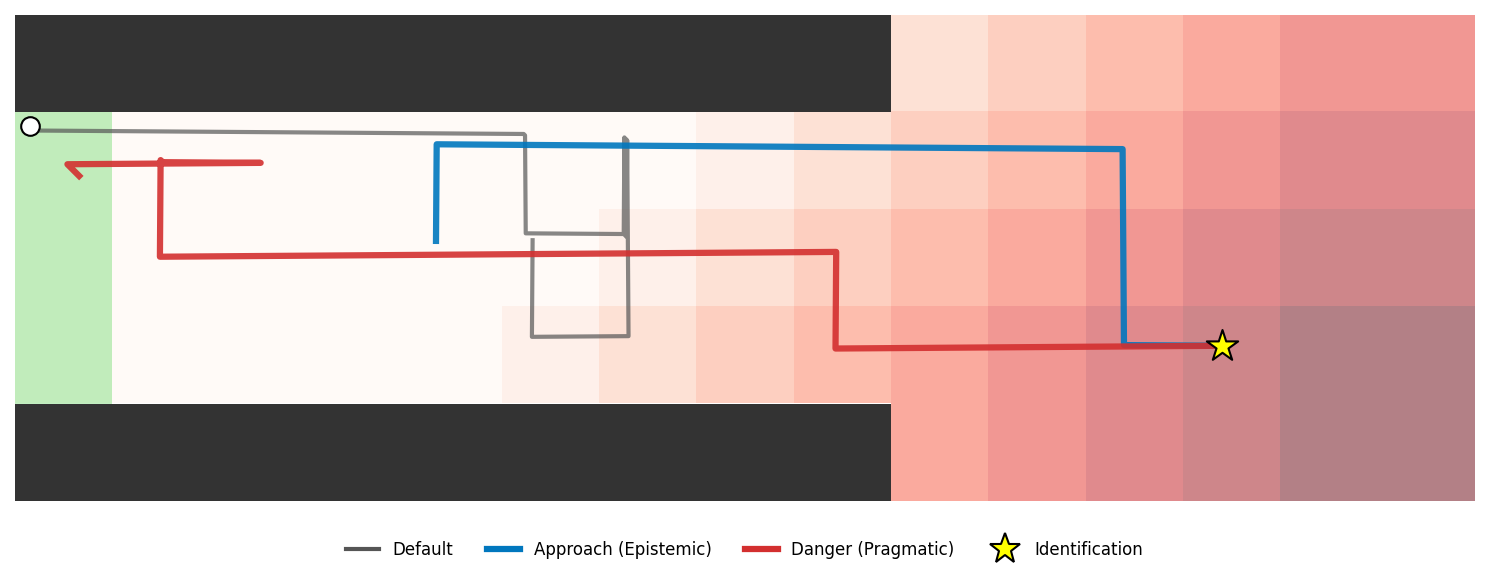

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines

# --- 1. CONFIGURATION & DATA ---

mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# --- 2. SENSORY GRADIENT LOGIC ---
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)] 
max_threat_intensity = 9

def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)


full_traj_coords = [(1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 5), (1, 5), (2, 5), (2, 6), (1, 6), (2, 6), (1, 6), (2, 6), (1, 6), (2, 6), (3, 6), (3, 5), (2, 5), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (2, 11), (3, 11), (3, 12), (3, 11), (3, 10), (3, 9), (3, 8), (2, 8), (2, 7), (2, 6), (2, 5), (2, 4), (2, 3), (2, 2), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 1), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0)]


# --- 4. PLOTTING FUNCTION ---

def draw_panel_a_jittered(traj_coords, grid_threat, mask):
    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    
    # A. Setup Grid
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5) # Matrix coordinates (Y increases down)
    ax.set_aspect('equal')
    ax.axis('off')

    # B. Backgrounds (Heatmap + Walls + Shelter)
    ax.imshow(grid_threat, cmap='Reds', alpha=0.5, vmin=0, vmax=max_threat_intensity, zorder=1)
    
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#333333', edgecolor='none', zorder=2))
    
    for r in range(rows):
        if mask[r, 0]:
             ax.add_patch(Rectangle((-0.5, r-0.5), 1, 1, facecolor='limegreen', alpha=0.3, zorder=2))

    # C. Jitter Logic
    # We apply a temporal offset to every point.
    # Matrix Coords: Top-Left is (c-0.5, r-0.5). Bottom-Right is (c+0.5, r+0.5).
    # To go diagonally Down-Right, we add positive offset to both X (col) and Y (row).
    
    T = len(traj_coords)
    max_offset = 0.35 # Max deviation from center in pixels (cell size = 1)
    
    jittered_x = []
    jittered_y = []
    
    for i, (r, c) in enumerate(traj_coords):
        # Time Factor (0.0 to 1.0)
        time_factor = i / max(1, T - 1)
        
        # Linearly interpolate from -offset (Top-Left) to +offset (Bottom-Right)
        # current_offset ranges from -0.35 to +0.35
        current_offset = -max_offset + (2 * max_offset * time_factor)
        
        jx = c + current_offset
        jy = r + current_offset # +offset is DOWN in matrix coords
        
        jittered_x.append(jx)
        jittered_y.append(jy)

    # D. Draw Segments by Phase
    # We slice the jittered arrays based on the time indices
    
    # Phase 1: Default (0-25)
    ax.plot(jittered_x[:25], jittered_y[:25], 
            color='#555555', linewidth=2, alpha=0.7, zorder=3, label='Default (Naive)')
            
    # Phase 2: Approach (25-35)
    ax.plot(jittered_x[25:37], jittered_y[25:37], 
            color='#0077BE', linewidth=3, alpha=0.9, zorder=4, label='Approach (Curiosity)')

    # Phase 3: Danger (35-72)
    # Includes flight and hiding
    ax.plot(jittered_x[36:73], jittered_y[36:73], 
            color='#D32F2F', linewidth=3, alpha=0.9, zorder=5, label='Danger (Fear)')

    # Phase 4: Default Back (72+)
    # ax.plot(jittered_x[72:], jittered_y[72:], 
    #         color='#555555', linewidth=2, alpha=0.7, zorder=3)

    # E. Markers
    # Start
    ax.scatter(jittered_x[0], jittered_y[0], s=80, c='white', edgecolors='black', zorder=6)
    # ID Event (t=35)
    ax.scatter(jittered_x[36], jittered_y[36], s=250, marker='*', c='yellow', edgecolors='black', linewidth=1, zorder=7)
    
    # F. Legend
    # Create custom handles for the 3 distinct behaviors
    legend_elements = [
        mlines.Line2D([], [], color='#555555', lw=2, label='Default'),
        mlines.Line2D([], [], color='#0077BE', lw=3, label='Approach (Epistemic)'),
        mlines.Line2D([], [], color='#D32F2F', lw=3, label='Danger (Pragmatic)'),
        mlines.Line2D([], [], marker='*', color='w', markerfacecolor='yellow', markeredgecolor='black', markersize=15, label='Identification'),
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False)

    plt.tight_layout()
    plt.show()

draw_panel_a_jittered(full_traj_coords, grid_threat, mask)

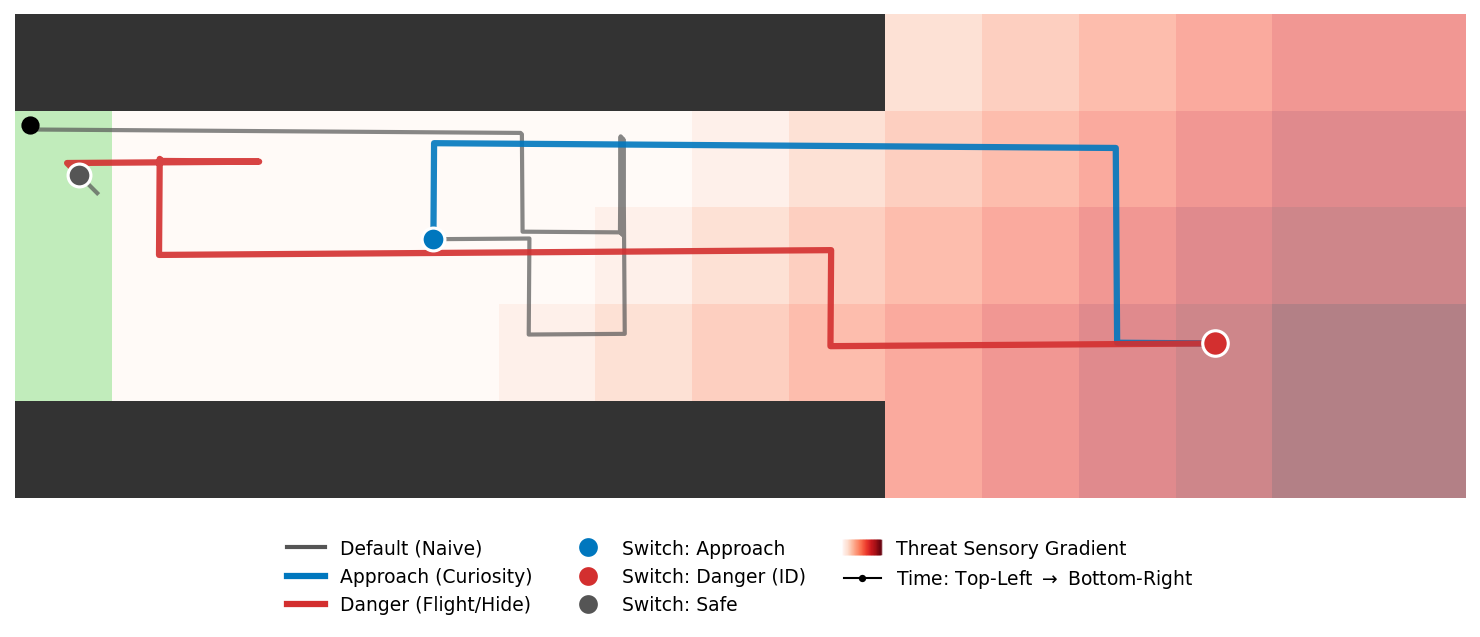

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.legend_handler import HandlerBase

# --- 1. CONFIGURATION & DATA ---
class GradientHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
            # We create a series of 100 thin vertical lines to form a smooth gradient
            n = 100
            x_values = np.linspace(xdescent, xdescent + width, n)
            colors = plt.cm.Reds(np.linspace(0, 1, n))
            
            lines = []
            for i in range(n):
                # Each line is a very thin vertical slice
                line = plt.Line2D([x_values[i], x_values[i]], [ydescent, ydescent + height],
                                color=colors[i], alpha=0.5, linewidth=width/n + 1, transform=trans)
                lines.append(line)
            return lines

mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# --- 2. SENSORY GRADIENT LOGIC ---
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)] 
max_threat_intensity = 9

def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)



full_traj_coords = [(1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 5), (1, 5), (2, 5), (2, 6), (1, 6), (2, 6), (1, 6), (2, 6), (1, 6), (2, 6), (3, 6), (3, 5), (2, 5), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (2, 11), (3, 11), (3, 12), (3, 11), (3, 10), (3, 9), (3, 8), (2, 8), (2, 7), (2, 6), (2, 5), (2, 4), (2, 3), (2, 2), (2, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 2), (1, 1), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0)]


# --- 4. PLOTTING FUNCTION ---

def draw_panel_a_final_refined(traj_coords, grid_threat, mask, filename=None):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150) # Increased height for legend
    
    # A. Setup Grid
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5) 
    ax.set_aspect('equal')
    ax.axis('off')

    # B. Backgrounds
    im = ax.imshow(grid_threat, cmap='Reds', alpha=0.5, vmin=0, vmax=max_threat_intensity, zorder=1)
    
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#333333', edgecolor='none', zorder=2))
    
    for r in range(rows):
        if mask[r, 0]:
             ax.add_patch(Rectangle((-0.5, r-0.5), 1, 1, facecolor='limegreen', alpha=0.3, zorder=2))

    # C. Jitter Logic
    T = len(traj_coords)
    max_offset = 0.35
    
    jittered_x = []
    jittered_y = []
    
    for i, (r, c) in enumerate(traj_coords):
        time_factor = i / max(1, T - 1)
        current_offset = -max_offset + (2 * max_offset * time_factor)
        jittered_x.append(c + current_offset)
        jittered_y.append(r + current_offset)

    # D. Draw Segments
    # Phase 1: Default (0-25)
    ax.plot(jittered_x[:26], jittered_y[:26], 
            color='#555555', linewidth=2, alpha=0.7, zorder=3)
            
    # Phase 2: Approach (25-36)
    ax.plot(jittered_x[25:37], jittered_y[25:37], 
            color='#0077BE', linewidth=3, alpha=0.9, zorder=4)

    # Phase 3: Danger (36-72)
    ax.plot(jittered_x[36:73], jittered_y[36:73], 
            color='#D32F2F', linewidth=3, alpha=0.9, zorder=5)

    # Phase 4: Default Back (72+)
    ax.plot(jittered_x[72:], jittered_y[72:], 
            color='#555555', linewidth=2, alpha=0.7, zorder=3)

    # E. Switch Markers (Circles)
    # t=25: Default -> Approach (Blue Circle)
    ax.scatter(jittered_x[25], jittered_y[25], s=120, facecolors='#0077BE', edgecolors='white', linewidth=1.5, zorder=6)
    # t=35: Approach -> Danger (Red Circle)
    ax.scatter(jittered_x[36], jittered_y[36], s=150, facecolors='#D32F2F', edgecolors='white', linewidth=1.5, zorder=7)
    # t=72: Danger -> Default (Grey Circle)
    ax.scatter(jittered_x[72], jittered_y[72], s=120, facecolors='#555555', edgecolors='white', linewidth=1.5, zorder=6)
    
    # Start Point
    ax.scatter(jittered_x[0], jittered_y[0], s=60, c='black', zorder=6)

    # F. Detailed Legend
    # We build a custom legend to explain visual encodings
    
    # 1. Behavior Lines
    line_def = mlines.Line2D([], [], color='#555555', lw=2, label='Default (Naive)')
    line_app = mlines.Line2D([], [], color='#0077BE', lw=3, label='Approach (Curiosity)')
    line_dan = mlines.Line2D([], [], color='#D32F2F', lw=3, label='Danger (Flight/Hide)')
    
    # 2. Event Markers
    mark_app = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#0077BE', markersize=10, label='Switch: Approach')
    mark_dan = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#D32F2F', markersize=10, label='Switch: Danger (ID)')
    mark_saf = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#555555', markersize=10, label='Switch: Safe')

    # 3. Environment & Time
    # Create a proxy artist for the Red Gradient
    patch_grad = mpatches.Rectangle((0, 0), 1, 1, label='Threat Sensory Gradient')

    line_time = mlines.Line2D([], [], color='black', lw=1, marker='.', markersize=5, linestyle='-', label='Time: Top-Left $\\to$ Bottom-Right')

    # Organize Legend
    handles = [line_def, line_app, line_dan, 
            mark_app, mark_dan, mark_saf,
            patch_grad, line_time]

    # Place legend and map the Rectangle to our custom GradientHandler
    ax.legend(handles=handles, 
            handler_map={mpatches.Rectangle: GradientHandler()},
            loc='upper center', 
            bbox_to_anchor=(0.5, -0.05), 
            ncol=3, 
            frameon=False, 
            fontsize=9)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()

draw_panel_a_final_refined(full_traj_coords, grid_threat, mask, 'example.svg')

In [ ]:
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    from matplotlib.patches import Rectangle
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.legend_handler import HandlerBase
    from matplotlib.animation import FFMpegWriter

    # ── your existing setup (mask, grid_threat, jittered_x/y, etc.) ──
    traj_coords = full_traj_coords
    # C. Jitter Logic
    T = len(traj_coords)
    max_offset = 0.35

    jittered_x = []
    jittered_y = []

    for i, (r, c) in enumerate(traj_coords):
        time_factor = i / max(1, T - 1)
        current_offset = -max_offset + (2 * max_offset * time_factor)
        jittered_x.append(c + current_offset)
        jittered_y.append(r + current_offset)

    PHASES = [
        dict(start=0,  end=25, color='#555555', lw=2, alpha=0.7, label='Default (Naive)'),
        dict(start=25, end=36, color='#0077BE', lw=3, alpha=0.9, label='Approach (Curiosity)'),
        dict(start=36, end=72, color='#D32F2F', lw=3, alpha=0.9, label='Danger (Flight/Hide)'),
        dict(start=72, end=len(full_traj_coords)-1, color='#555555', lw=2, alpha=0.7, label='Default (Return)'),
    ]
    FPS = 60
    DURATION_S = 5

    def make_phase_gif(phase_idx, filename):
        ph = PHASES[phase_idx]
        seg_x = jittered_x[ph['start']:ph['end']+1]
        seg_y = jittered_y[ph['start']:ph['end']+1]
        n_frames = FPS * DURATION_S

        fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(rows - 0.5, -0.5)
        ax.set_aspect('equal')
        ax.axis('off')

        # ── static background ──
        ax.imshow(grid_threat, cmap='Reds', alpha=0.5, vmin=0, vmax=max_threat_intensity, zorder=1)
        for r in range(rows):
            for c in range(cols):
                if not mask[r, c]:
                    ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#333333', edgecolor='none', zorder=2))
        for r in range(rows):
            if mask[r, 0]:
                ax.add_patch(Rectangle((-0.5, r-0.5), 1, 1, facecolor='limegreen', alpha=0.3, zorder=2))

        # ── draw all previous phases statically ──
        for prev in PHASES[:phase_idx]:
            ax.plot(jittered_x[prev['start']:prev['end']+1],
                    jittered_y[prev['start']:prev['end']+1],
                    color=prev['color'], lw=prev['lw'], alpha=prev['alpha'], zorder=3)

        # ── switch markers for all previous transitions ──
        switch_pts = [25, 36, 72]
        switch_colors = ['#0077BE', '#D32F2F', '#555555']
        for i in range(phase_idx):
            if i < len(switch_pts):
                ax.scatter(jittered_x[switch_pts[i]], jittered_y[switch_pts[i]],
                        s=120, facecolors=switch_colors[i], edgecolors='white', lw=1.5, zorder=8)

        # ── start dot ──
        ax.scatter(jittered_x[0], jittered_y[0], s=60, c='black', zorder=10)

        # ── animated line (starts empty) ──
        anim_line, = ax.plot([], [], color=ph['color'], lw=ph['lw'], alpha=ph['alpha'], zorder=5)
        # moving dot
        dot, = ax.plot([], [], 'o', color=ph['color'], ms=7, zorder=6)

        def init():
            anim_line.set_data([], [])
            dot.set_data([], [])
            return anim_line, dot

        def update(frame):
            # map frame → index along this segment
            t = frame / (n_frames - 1)          # 0 → 1
            idx = max(1, int(t * (len(seg_x) - 1)) + 1)
            anim_line.set_data(seg_x[:idx], seg_y[:idx])
            dot.set_data([seg_x[idx-1]], [seg_y[idx-1]])
            return anim_line, dot

        ani = FuncAnimation(fig, update, frames=n_frames,
                            init_func=init, blit=True, interval=1000/FPS)
        # ani.save(filename, writer=PillowWriter(fps=FPS))
        writer = FFMpegWriter(fps=FPS, bitrate=1800)
        ani.save(filename.replace('.gif', '.mp4'), writer=writer)
        plt.close()
        print(f"Saved {filename}")

    for i in range(4):
        make_phase_gif(i, f'phase_{i+1}_anim.gif')

Saved phase_1_anim.gif
Saved phase_2_anim.gif
Saved phase_3_anim.gif
Saved phase_4_anim.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation, FFMpegWriter
import re

# ── Belief Data Parser ──────────────────────────────────────────────────────
t_beliefs_raw = """
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000541126636), np.float64(0.4999999458873364)]
[np.float64(0.5000000959203315), np.float64(0.49999990407966854)]
[np.float64(0.5000001308490718), np.float64(0.49999986915092814)]
[np.float64(0.5000001573095696), np.float64(0.49999984269043046)]
[np.float64(0.500000179960554), np.float64(0.49999982003944593)]
[np.float64(0.5000001965988267), np.float64(0.49999980340117334)]
[np.float64(0.5000002113920184), np.float64(0.4999997886079816)]
[np.float64(0.5000002217440438), np.float64(0.49999977825595615)]
[np.float64(0.5000002307566589), np.float64(0.49999976924334116)]
[np.float64(0.5000002372357842), np.float64(0.4999997627642157)]
[np.float64(0.5000002439016451), np.float64(0.499999756098355)]
[np.float64(0.5000002492343437), np.float64(0.4999997507656563)]
[np.float64(0.5000002535005106), np.float64(0.4999997464994894)]
[np.float64(0.5000002937928925), np.float64(0.49999970620710754)]
[np.float64(0.5000003994387354), np.float64(0.4999996005612645)]
[np.float64(0.5000004838458507), np.float64(0.49999951615414917)]
[np.float64(0.5000005404760376), np.float64(0.4999994595239624)]
[np.float64(0.5000005670635777), np.float64(0.49999943293642246)]
[np.float64(0.5000005670415848), np.float64(0.4999994329584152)]
[np.float64(0.5000005472006411), np.float64(0.49999945279935887)]
[np.float64(0.5000005150965577), np.float64(0.49999948490344226)]
[np.float64(0.49759018313657133), np.float64(0.5024098168634287)]
[np.float64(0.19765638487606227), np.float64(0.8023436151239377)]
[np.float64(0.24644663705040198), np.float64(0.7535533629495981)]
[np.float64(0.2971573111973973), np.float64(0.7028426888026028)]
[np.float64(0.999999999999998), np.float64(2.0458081862568194e-15)]
[np.float64(0.9999999999999998), np.float64(1.1584042076546208e-16)]
[np.float64(0.9999999999999998), np.float64(1.1580975098565103e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579754398499454e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579268560476936e-16)]
[np.float64(0.9999999999999998), np.float64(1.157907519997926e-16)]
[np.float64(0.9999999999999998), np.float64(1.157899824415212e-16)]
[np.float64(0.9999999999999998), np.float64(1.157896761646034e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578955426939611e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578950575631748e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578948644859933e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894787643228e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947570605704e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894744889015e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947400448495e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947381169375e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894737349648e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947370442573e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947369227478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368743958e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736855144e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736847476e-16)]
[np.float64(0.9999999999999998), np.float64(1.15789473684444e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368432141e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368427453e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368425478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424738e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424243e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
"""

def parse_beliefs(bel_str):
    data = []
    for line in bel_str.strip().split('\n'):
        if not line:
            continue
        clean = line.replace('[', '').replace(']', '').replace('np.float64(', '').replace(')', '')
        parts = clean.split(',')
        vals = [float(p.strip()) for p in parts if p.strip()]
        if vals:
            data.append(vals)
    return np.array(data)

T_data = parse_beliefs(t_beliefs_raw)
N_TRAJ = len(T_data)  # total trajectory steps

# ── Trajectory Setup ─────────────────────────────────────────────────────────
# REPLACE with your actual traj_coords, mask, grid_threat, rows, cols etc.
# ── Placeholder: build a dummy environment if not already defined ──
try:
    traj_coords = full_traj_coords
except NameError:
    # Synthetic stand-in so the script is self-contained / testable
    np.random.seed(42)
    rows, cols = 20, 30
    mask = np.ones((rows, cols), dtype=bool)
    grid_threat = np.zeros((rows, cols))
    grid_threat[8:14, 14:22] = np.random.rand(6, 8) * 3
    max_threat_intensity = grid_threat.max()

    # A simple path: drift right then flee
    path = []
    r, c = 10, 0
    for i in range(N_TRAJ):
        path.append((r, c))
        if i < 25:
            c = min(c + 1, cols - 1)
        elif i < 36:
            c = min(c + 1, cols - 1)
            r = max(r - 0, 0)
        elif i < 72:
            c = max(c - 1, 0)
            r = min(r + (1 if i % 3 == 0 else 0), rows - 1)
        else:
            c = max(c - 1, 0)
    traj_coords = path
    print("Using synthetic trajectory — replace with your full_traj_coords.")

# ── Jitter ────────────────────────────────────────────────────────────────────
T_len = len(traj_coords)
max_offset = 0.35
jittered_x, jittered_y = [], []
for i, (r, c) in enumerate(traj_coords):
    tf = i / max(1, T_len - 1)
    offset = -max_offset + 2 * max_offset * tf
    jittered_x.append(c + offset)
    jittered_y.append(r + offset)

# ── Phase definitions ─────────────────────────────────────────────────────────
PHASES = [
    dict(start=0,  end=25, color='#555555', lw=2, alpha=0.7,  label='Default (Spatio-Motor Controls)'),
    dict(start=25, end=36, color='#0077BE', lw=3, alpha=0.9,  label='Approach (Threat Identification Controls)'),
    dict(start=36, end=72, color='#D32F2F', lw=3, alpha=0.9,  label='Flight (Danger Context Controls)'),
    dict(start=72, end=T_len - 1, color='#555555', lw=2, alpha=0.7, label='Default (Return)'),
]
SWITCH_PTS    = [25, 36, 72]
SWITCH_COLORS = ['#0077BE', '#D32F2F', '#555555']

# ── Animation parameters ──────────────────────────────────────────────────────
FPS           = 60
TRAJ_DURATION = 12          # seconds to animate the full trajectory
PAUSE_DURATION = 1.5        # seconds to pause at each phase transition

# Build a per-step frame schedule:
# Each trajectory step gets a base number of frames, plus bonus frames at transitions.
BASE_FRAMES_PER_STEP = int(FPS * TRAJ_DURATION / T_len)
PAUSE_FRAMES          = int(FPS * PAUSE_DURATION)

# frame_to_step[f] → which trajectory step is shown at frame f
frame_to_step = []
for step in range(T_len):
    reps = BASE_FRAMES_PER_STEP
    if step in SWITCH_PTS:
        reps += PAUSE_FRAMES
    frame_to_step.extend([step] * reps)

TOTAL_FRAMES = len(frame_to_step)

# ── Build figure ──────────────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})
fig = plt.figure(figsize=(18, 8), dpi=100)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1.4, 1],
                        height_ratios=[1, 1],
                        hspace=0.38, wspace=0.30)

ax_map  = fig.add_subplot(gs[:, 0])   # full left column: trajectory map
ax_bel  = fig.add_subplot(gs[0, 1])   # top-right: belief probability
ax_drv  = fig.add_subplot(gs[1, 1])   # bottom-right: drives

fig.patch.set_facecolor('white')
for ax in [ax_map, ax_bel, ax_drv]:
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_color('#cccccc')
    ax.tick_params(colors='black', labelsize=9)
    ax.yaxis.label.set_color('black')
    ax.xaxis.label.set_color('black')
    ax.title.set_color('black')

# ── Map: static background ────────────────────────────────────────────────────
ax_map.set_xlim(-0.5, cols - 0.5)
ax_map.set_ylim(rows - 0.5, -0.5)
ax_map.set_aspect('equal')
ax_map.axis('off')
ax_map.imshow(grid_threat, cmap='Reds', alpha=0.9,
              vmin=0, vmax=max_threat_intensity, zorder=1)
for r in range(rows):
    for c in range(cols):
        if not mask[r, c]:
            ax_map.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor='#aaaaaa', edgecolor='none', zorder=2))
# Safe zone (left column)
for r in range(rows):
    if mask[r, 0]:
        ax_map.add_patch(Rectangle((-0.5, r - 0.5), 1, 1,
                                   facecolor='limegreen', alpha=0.9, zorder=2))
ax_map.scatter(jittered_x[0], jittered_y[0], s=70, c='black', zorder=10)

# Phase legend — placed below the map axes
legend_patches = [mpatches.Patch(color=ph['color'], alpha=ph['alpha'], label=ph['label'])
                  for ph in PHASES]
ax_map.legend(handles=legend_patches,
              loc='upper center', bbox_to_anchor=(0.5, -0.03),
              ncol=4, frameon=False, fontsize=8,
              labelcolor='black')
ax_map.set_title('Agent Trajectory', fontweight='bold', color='black', fontsize=12)

# ── Belief panel: static elements ─────────────────────────────────────────────
t_axis = np.arange(N_TRAJ)
threat_prob = T_data[:, 1]

ax_bel.axhline(0.75, color='#7755bb', linestyle='--', linewidth=1, alpha=0.7, label='Threshold')
ax_bel.set_xlim(0, N_TRAJ - 1)
ax_bel.set_ylim(-0.05, 1.05)
ax_bel.set_ylabel('Belief P(Threat)', fontsize=8)
ax_bel.set_title('Threat Identity Beliefs', fontweight='bold', fontsize=9, loc='left')

# Danger context shading (static)
ax_bel.axvspan(36, 72, color='#D32F2F', alpha=0.08)
ax_drv.axvspan(36, 72, color='#D32F2F', alpha=0.08)

# ── Drive panel: static reference lines ───────────────────────────────────────
epistemic_drive = np.zeros(N_TRAJ)
epistemic_drive[25:36] = 0.85
pragmatic_drive = np.zeros(N_TRAJ)
pragmatic_drive[36:72] = 0.90

# Draw full drives as faint background guides
ax_drv.fill_between(t_axis, epistemic_drive, color='#0077BE', alpha=0.08)
ax_drv.fill_between(t_axis, pragmatic_drive, color='#2a9d3f', alpha=0.08)
ax_drv.set_xlim(0, N_TRAJ - 1)
ax_drv.set_ylim(-0.05, 1.05)
ax_drv.set_ylabel('Drive Magnitude', fontsize=8)
ax_drv.set_xlabel('Simulation Step', fontsize=8)
ax_drv.set_title('Competition of Drives', fontweight='bold', fontsize=9, loc='left')

# ── Animated artists ──────────────────────────────────────────────────────────
# Map: one line per phase (we'll grow them independently)
phase_lines = []
for ph in PHASES:
    line, = ax_map.plot([], [], color=ph['color'], lw=ph['lw'],
                        alpha=ph['alpha'], zorder=3, solid_capstyle='round')
    phase_lines.append(line)

move_dot, = ax_map.plot([], [], 'o', color='white', ms=6, zorder=7)
switch_dots = []   # scatter artists for phase-transition markers (added dynamically)

# Belief lines
bel_line_threat, = ax_bel.plot([], [], color='#0077BE', lw=2, label='P(Threat)')
bel_line_not,    = ax_bel.plot([], [], color='#888888', lw=1.5, ls=':', label='P(Not Threat)')
bel_dot,         = ax_bel.plot([], [], 'o', color='#7755bb', ms=5, zorder=5)
threshold_dot,   = ax_bel.plot([], [], 's', color='#7755bb', ms=6, zorder=6)

ax_bel.legend(loc='upper left', frameon=False, labelcolor='black', fontsize=7.5)

# Drive lines
drv_epi,  = ax_drv.plot([], [], color='#0077BE', lw=2, label='Epistemic (Curiosity)')
drv_epi_f = ax_drv.fill_between([], [], color='#0077BE', alpha=0)  # placeholder
drv_prg,  = ax_drv.plot([], [], color='#2a9d3f', lw=2, label='Pragmatic (Safety)')
drv_prg_f = ax_drv.fill_between([], [], color='#2a9d3f', alpha=0)  # placeholder

ax_drv.legend(loc='upper left', frameon=False, labelcolor='black', fontsize=7.5)

# Step label
step_text = ax_map.text(0.02, 0.97, '', transform=ax_map.transAxes,
                        fontsize=9, color='black', va='top')

# Track which switch markers have been drawn
switches_drawn = set()

plt.tight_layout(rect=[0, 0.04, 1, 1])

# ── Update function ───────────────────────────────────────────────────────────
def init():
    for pl in phase_lines:
        pl.set_data([], [])
    move_dot.set_data([], [])
    bel_line_threat.set_data([], [])
    bel_line_not.set_data([], [])
    bel_dot.set_data([], [])
    drv_epi.set_data([], [])
    drv_prg.set_data([], [])
    step_text.set_text('')
    return (*phase_lines, move_dot, bel_line_threat, bel_line_not, bel_dot, drv_epi, drv_prg, step_text)

def update(frame):
    step = frame_to_step[frame]
    step = min(step, T_len - 1)

    # ── Map: grow each phase line up to current step ──
    for ph_idx, ph in enumerate(PHASES):
        s, e = ph['start'], min(ph['end'], step)
        if step >= ph['start']:
            seg_x = jittered_x[ph['start']:e + 1]
            seg_y = jittered_y[ph['start']:e + 1]
            phase_lines[ph_idx].set_data(seg_x, seg_y)

    # Moving dot
    move_dot.set_data([jittered_x[step]], [jittered_y[step]])

    # Phase switch markers (appear once, persist)
    for si, sp in enumerate(SWITCH_PTS):
        if step >= sp and sp not in switches_drawn:
            ax_map.scatter(jittered_x[sp], jittered_y[sp],
                           s=130, facecolors=SWITCH_COLORS[si],
                           edgecolors='black', lw=1.5, zorder=8)
            switches_drawn.add(sp)

    step_text.set_text(f'Step: {step}')

    # ── Beliefs ──
    s_bel = min(step + 1, N_TRAJ)
    bel_line_threat.set_data(t_axis[:s_bel], threat_prob[:s_bel])
    bel_line_not.set_data(t_axis[:s_bel], T_data[:s_bel, 0])
    if s_bel > 0:
        bel_dot.set_data([t_axis[s_bel - 1]], [threat_prob[s_bel - 1]])
        # Highlight threshold crossing
        if threat_prob[s_bel - 1] >= 0.75:
            threshold_dot.set_data([t_axis[s_bel - 1]], [threat_prob[s_bel - 1]])
        else:
            threshold_dot.set_data([], [])

    # ── Drives ──
    drv_epi.set_data(t_axis[:s_bel], epistemic_drive[:s_bel])
    drv_prg.set_data(t_axis[:s_bel], pragmatic_drive[:s_bel])

    return (*phase_lines, move_dot, bel_line_threat, bel_line_not,
            bel_dot, threshold_dot, drv_epi, drv_prg, step_text)

# ── Render ────────────────────────────────────────────────────────────────────
ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES,
                    init_func=init, blit=False, interval=1000 / FPS)

out_path = 'combined_trajectory_new.mp4'
writer = FFMpegWriter(fps=FPS, bitrate=2500,
                      extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
ani.save(out_path, writer=writer)
plt.close()
print(f"Saved → {out_path}")

/tmp/ipykernel_2448/1154470674.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved → combined_trajectory_new.mp4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation, FFMpegWriter
import re

# ── Belief Data Parser ──────────────────────────────────────────────────────
t_beliefs_raw = """
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000000000002), np.float64(0.49999999999999983)]
[np.float64(0.5000000541126636), np.float64(0.4999999458873364)]
[np.float64(0.5000000959203315), np.float64(0.49999990407966854)]
[np.float64(0.5000001308490718), np.float64(0.49999986915092814)]
[np.float64(0.5000001573095696), np.float64(0.49999984269043046)]
[np.float64(0.500000179960554), np.float64(0.49999982003944593)]
[np.float64(0.5000001965988267), np.float64(0.49999980340117334)]
[np.float64(0.5000002113920184), np.float64(0.4999997886079816)]
[np.float64(0.5000002217440438), np.float64(0.49999977825595615)]
[np.float64(0.5000002307566589), np.float64(0.49999976924334116)]
[np.float64(0.5000002372357842), np.float64(0.4999997627642157)]
[np.float64(0.5000002439016451), np.float64(0.499999756098355)]
[np.float64(0.5000002492343437), np.float64(0.4999997507656563)]
[np.float64(0.5000002535005106), np.float64(0.4999997464994894)]
[np.float64(0.5000002937928925), np.float64(0.49999970620710754)]
[np.float64(0.5000003994387354), np.float64(0.4999996005612645)]
[np.float64(0.5000004838458507), np.float64(0.49999951615414917)]
[np.float64(0.5000005404760376), np.float64(0.4999994595239624)]
[np.float64(0.5000005670635777), np.float64(0.49999943293642246)]
[np.float64(0.5000005670415848), np.float64(0.4999994329584152)]
[np.float64(0.5000005472006411), np.float64(0.49999945279935887)]
[np.float64(0.5000005150965577), np.float64(0.49999948490344226)]
[np.float64(0.49759018313657133), np.float64(0.5024098168634287)]
[np.float64(0.19765638487606227), np.float64(0.8023436151239377)]
[np.float64(0.24644663705040198), np.float64(0.7535533629495981)]
[np.float64(0.2971573111973973), np.float64(0.7028426888026028)]
[np.float64(0.999999999999998), np.float64(2.0458081862568194e-15)]
[np.float64(0.9999999999999998), np.float64(1.1584042076546208e-16)]
[np.float64(0.9999999999999998), np.float64(1.1580975098565103e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579754398499454e-16)]
[np.float64(0.9999999999999998), np.float64(1.1579268560476936e-16)]
[np.float64(0.9999999999999998), np.float64(1.157907519997926e-16)]
[np.float64(0.9999999999999998), np.float64(1.157899824415212e-16)]
[np.float64(0.9999999999999998), np.float64(1.157896761646034e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578955426939611e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578950575631748e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578948644859933e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894787643228e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947570605704e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894744889015e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947400448495e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947381169375e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894737349648e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947370442573e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947369227478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368743958e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736855144e-16)]
[np.float64(0.9999999999999998), np.float64(1.157894736847476e-16)]
[np.float64(0.9999999999999998), np.float64(1.15789473684444e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368432141e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368427453e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368425478e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424738e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424243e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424327e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
[np.float64(0.9999999999999998), np.float64(1.1578947368424408e-16)]
"""

def parse_beliefs(bel_str):
    data = []
    for line in bel_str.strip().split('\n'):
        if not line:
            continue
        clean = line.replace('[', '').replace(']', '').replace('np.float64(', '').replace(')', '')
        parts = clean.split(',')
        vals = [float(p.strip()) for p in parts if p.strip()]
        if vals:
            data.append(vals)
    return np.array(data)

T_data = parse_beliefs(t_beliefs_raw)
N_TRAJ = len(T_data)  # total trajectory steps

# ── Trajectory Setup ─────────────────────────────────────────────────────────
# REPLACE with your actual traj_coords, mask, grid_threat, rows, cols etc.
# ── Placeholder: build a dummy environment if not already defined ──
try:
    traj_coords = full_traj_coords
except NameError:
    # Synthetic stand-in so the script is self-contained / testable
    np.random.seed(42)
    rows, cols = 20, 30
    mask = np.ones((rows, cols), dtype=bool)
    grid_threat = np.zeros((rows, cols))
    grid_threat[8:14, 14:22] = np.random.rand(6, 8) * 3
    max_threat_intensity = grid_threat.max()

    # A simple path: drift right then flee
    path = []
    r, c = 10, 0
    for i in range(N_TRAJ):
        path.append((r, c))
        if i < 25:
            c = min(c + 1, cols - 1)
        elif i < 36:
            c = min(c + 1, cols - 1)
            r = max(r - 0, 0)
        elif i < 72:
            c = max(c - 1, 0)
            r = min(r + (1 if i % 3 == 0 else 0), rows - 1)
        else:
            c = max(c - 1, 0)
    traj_coords = path
    print("Using synthetic trajectory — replace with your full_traj_coords.")

# ── Jitter ────────────────────────────────────────────────────────────────────
T_len = len(traj_coords)
max_offset = 0.35
jittered_x, jittered_y = [], []
for i, (r, c) in enumerate(traj_coords):
    tf = i / max(1, T_len - 1)
    offset = -max_offset + 2 * max_offset * tf
    jittered_x.append(c + offset)
    jittered_y.append(r + offset)

# ── Phase definitions ─────────────────────────────────────────────────────────
PHASES = [
    dict(start=0,  end=25, color='#555555', lw=2, alpha=0.7,  label='Default (Spatio-Motor Controls)'),
    dict(start=25, end=36, color='#0077BE', lw=3, alpha=0.9,  label='Approach (Threat Identification Controls)'),
    dict(start=36, end=72, color='#D32F2F', lw=3, alpha=0.9,  label='Flight (Danger Context Controls)'),
    dict(start=72, end=T_len - 1, color='#555555', lw=2, alpha=0.7, label='Default (Return)'),
]
SWITCH_PTS    = [25, 36, 72]
SWITCH_COLORS = ['#0077BE', '#D32F2F', '#555555']

# ── Animation parameters ──────────────────────────────────────────────────────
SPLIT_BY_PHASE = True       # True → 4 per-phase videos; False → one combined video

FPS           = 60
TRAJ_DURATION = 12          # seconds to animate the full trajectory
PAUSE_DURATION = 1.5        # seconds to pause at each phase transition

# Build a per-step frame schedule for a given step range.
# Each step gets a base number of frames; switch-point steps get an extra pause.
BASE_FRAMES_PER_STEP = int(FPS * TRAJ_DURATION / T_len)
PAUSE_FRAMES          = int(FPS * PAUSE_DURATION)

def build_frame_schedule(step_range):
    schedule = []
    for step in step_range:
        reps = BASE_FRAMES_PER_STEP
        if step in SWITCH_PTS:
            reps += PAUSE_FRAMES
        schedule.extend([step] * reps)
    return schedule

# Combined schedule (used when SPLIT_BY_PHASE is False)
frame_to_step_combined = build_frame_schedule(range(T_len))
TOTAL_FRAMES_COMBINED  = len(frame_to_step_combined)

# ── Build figure ──────────────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})
fig = plt.figure(figsize=(18, 8), dpi=100)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[1.4, 1],
                        height_ratios=[1, 1],
                        hspace=0.38, wspace=0.30)

# ax_map  = fig.add_subplot(gs[:, 0])   # full left column: trajectory map
ax_map  = fig.add_subplot(gs[1, 0])   # bottom-left cell only: trajectory map
ax_bel  = fig.add_subplot(gs[0, 1])   # top-right: belief probability
ax_drv  = fig.add_subplot(gs[1, 1])   # bottom-right: drives

fig.patch.set_facecolor('white')
for ax in [ax_map, ax_bel, ax_drv]:
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_color('#cccccc')
    ax.tick_params(colors='black', labelsize=9)
    ax.yaxis.label.set_color('black')
    ax.xaxis.label.set_color('black')
    ax.title.set_color('black')

# ── Map: static background ────────────────────────────────────────────────────
ax_map.set_xlim(-0.5, cols - 0.5)
ax_map.set_ylim(rows - 0.5, -0.5)
ax_map.set_aspect('equal')
ax_map.axis('off')
ax_map.imshow(grid_threat, cmap='Reds', alpha=0.9,
              vmin=0, vmax=max_threat_intensity, zorder=1)
for r in range(rows):
    for c in range(cols):
        if not mask[r, c]:
            ax_map.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor='#aaaaaa', edgecolor='none', zorder=2))
# Safe zone (left column)
for r in range(rows):
    if mask[r, 0]:
        ax_map.add_patch(Rectangle((-0.5, r - 0.5), 1, 1,
                                   facecolor='limegreen', alpha=0.9, zorder=2))
ax_map.scatter(jittered_x[0], jittered_y[0], s=70, c='black', zorder=10)

# Phase legend — placed below the map axes
legend_patches = [mpatches.Patch(color=ph['color'], alpha=ph['alpha'], label=ph['label'])
                  for ph in PHASES]
ax_map.legend(handles=legend_patches,
              loc='upper center', bbox_to_anchor=(0.5, -0.03),
              ncol=4, frameon=False, fontsize=8,
              labelcolor='black')
ax_map.set_title('Agent Trajectory', fontweight='bold', color='black', fontsize=12)

# ── Belief panel: static elements ─────────────────────────────────────────────
t_axis = np.arange(N_TRAJ)
threat_prob = T_data[:, 1]

ax_bel.axhline(0.75, color='#7755bb', linestyle='--', linewidth=1, alpha=0.7, label='Threshold')
ax_bel.set_xlim(0, N_TRAJ - 1)
ax_bel.set_ylim(-0.05, 1.05)
ax_bel.set_ylabel('Belief P(Threat)', fontsize=8)
ax_bel.set_title('Threat Identity Beliefs', fontweight='bold', fontsize=9, loc='left')

# Danger context shading (static)
ax_bel.axvspan(36, 72, color='#D32F2F', alpha=0.08)
ax_drv.axvspan(36, 72, color='#D32F2F', alpha=0.08)

# ── Drive panel: static reference lines ───────────────────────────────────────
epistemic_drive = np.zeros(N_TRAJ)
epistemic_drive[25:36] = 0.85
pragmatic_drive = np.zeros(N_TRAJ)
pragmatic_drive[36:72] = 0.90

# Draw full drives as faint background guides
ax_drv.fill_between(t_axis, epistemic_drive, color='#0077BE', alpha=0.08)
ax_drv.fill_between(t_axis, pragmatic_drive, color='#2a9d3f', alpha=0.08)
ax_drv.set_xlim(0, N_TRAJ - 1)
ax_drv.set_ylim(-0.05, 1.05)
ax_drv.set_ylabel('Drive Magnitude', fontsize=8)
ax_drv.set_xlabel('Simulation Step', fontsize=8)
ax_drv.set_title('Competition of Drives', fontweight='bold', fontsize=9, loc='left')

# ── Animated artists ──────────────────────────────────────────────────────────
# Map: one line per phase (we'll grow them independently)
phase_lines = []
for ph in PHASES:
    line, = ax_map.plot([], [], color=ph['color'], lw=ph['lw'],
                        alpha=ph['alpha'], zorder=3, solid_capstyle='round')
    phase_lines.append(line)

move_dot, = ax_map.plot([], [], 'o', color='white', ms=6, zorder=7)
switch_dots = []   # scatter artists for phase-transition markers (added dynamically)

# Belief lines
bel_line_threat, = ax_bel.plot([], [], color='#0077BE', lw=2, label='P(Threat)')
bel_line_not,    = ax_bel.plot([], [], color='#888888', lw=1.5, ls=':', label='P(Not Threat)')
bel_dot,         = ax_bel.plot([], [], 'o', color='#7755bb', ms=5, zorder=5)
threshold_dot,   = ax_bel.plot([], [], 's', color='#7755bb', ms=6, zorder=6)

ax_bel.legend(loc='upper right', frameon=False, labelcolor='black', fontsize=7.5)

# Drive lines
drv_epi,  = ax_drv.plot([], [], color='#0077BE', lw=2, label='Epistemic (Curiosity)')
drv_epi_f = ax_drv.fill_between([], [], color='#0077BE', alpha=0)  # placeholder
drv_prg,  = ax_drv.plot([], [], color='#2a9d3f', lw=2, label='Pragmatic (Safety)')
drv_prg_f = ax_drv.fill_between([], [], color='#2a9d3f', alpha=0)  # placeholder

ax_drv.legend(loc='upper right', frameon=False, labelcolor='black', fontsize=7.5)

# Step label
step_text = ax_map.text(0.02, 0.97, '', transform=ax_map.transAxes,
                        fontsize=9, color='black', va='top')

# Track which switch markers have been drawn
switches_drawn = set()

plt.tight_layout(rect=[0, 0.04, 1, 1])

# ── Update function ───────────────────────────────────────────────────────────
def init():
    for pl in phase_lines:
        pl.set_data([], [])
    move_dot.set_data([], [])
    bel_line_threat.set_data([], [])
    bel_line_not.set_data([], [])
    bel_dot.set_data([], [])
    drv_epi.set_data([], [])
    drv_prg.set_data([], [])
    step_text.set_text('')
    return (*phase_lines, move_dot, bel_line_threat, bel_line_not, bel_dot, drv_epi, drv_prg, step_text)

def update(frame):
    step = _active_schedule[frame]
    step = min(step, T_len - 1)

    # ── Map: grow each phase line up to current step ──
    for ph_idx, ph in enumerate(PHASES):
        s, e = ph['start'], min(ph['end'], step)
        if step >= ph['start']:
            seg_x = jittered_x[ph['start']:e + 1]
            seg_y = jittered_y[ph['start']:e + 1]
            phase_lines[ph_idx].set_data(seg_x, seg_y)

    # Moving dot
    move_dot.set_data([jittered_x[step]], [jittered_y[step]])

    # Phase switch markers (appear once, persist)
    for si, sp in enumerate(SWITCH_PTS):
        if step >= sp and sp not in switches_drawn:
            ax_map.scatter(jittered_x[sp], jittered_y[sp],
                           s=130, facecolors=SWITCH_COLORS[si],
                           edgecolors='black', lw=1.5, zorder=8)
            switches_drawn.add(sp)

    step_text.set_text(f'Step: {step}')

    # ── Beliefs ──
    s_bel = min(step + 1, N_TRAJ)
    bel_line_threat.set_data(t_axis[:s_bel], threat_prob[:s_bel])
    bel_line_not.set_data(t_axis[:s_bel], T_data[:s_bel, 0])
    if s_bel > 0:
        bel_dot.set_data([t_axis[s_bel - 1]], [threat_prob[s_bel - 1]])
        # Highlight threshold crossing
        if threat_prob[s_bel - 1] >= 0.75:
            threshold_dot.set_data([t_axis[s_bel - 1]], [threat_prob[s_bel - 1]])
        else:
            threshold_dot.set_data([], [])

    # ── Drives ──
    drv_epi.set_data(t_axis[:s_bel], epistemic_drive[:s_bel])
    drv_prg.set_data(t_axis[:s_bel], pragmatic_drive[:s_bel])

    return (*phase_lines, move_dot, bel_line_threat, bel_line_not,
            bel_dot, threshold_dot, drv_epi, drv_prg, step_text)

# ── Render ────────────────────────────────────────────────────────────────────
writer = FFMpegWriter(fps=FPS, bitrate=2500,
                      extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])

def save_animation(schedule, out_path):
    """Render and save one video using the given frame→step schedule."""
    global _active_schedule, switches_drawn
    _active_schedule = schedule
    switches_drawn = set()   # reset so markers re-draw correctly per video
    # Reset all animated artists to blank
    init()
    ani = FuncAnimation(fig, update, frames=len(schedule),
                        init_func=init, blit=False, interval=1000 / FPS)
    ani.save(out_path, writer=writer)
    print(f"Saved → {out_path}")

if SPLIT_BY_PHASE:
    for ph_idx, ph in enumerate(PHASES):
        schedule = build_frame_schedule(range(ph['start'], ph['end'] + 1))
        label = ph['label'].split()[0].lower()   # e.g. "default", "approach", "danger"
        out_path = f'phase_{ph_idx + 1}_{label}.mp4'
        save_animation(schedule, out_path)
else:
    save_animation(frame_to_step_combined,
                   '/mnt/user-data/outputs/combined_trajectory.mp4')

plt.close()

/tmp/ipykernel_2448/1903861460.py:314: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Saved → phase_1_default.mp4
Saved → phase_2_approach.mp4
Saved → phase_3_flight.mp4
Saved → phase_4_default.mp4


In [ ]:
import matplotlib.pyplot as plt

# Data provided
data = [
    0.391049869, 0.553811039, 0.645734724, 0.618740656, 0.423745206, 
    0.919833318, 0.559523607, 0.382517973, 0.541910202, 0.530446353, 
    0.993559258, 0.922388205, 0.490251636, 0.412601503, 0.499879986, 
    0.557960572, 0.531513562, 0.63264524, 0.614968834, 0.89440483, 
    0.601808386, 0.935093578, 0.471112159, 0.354476139, 1.019444293, 
    0.69879897
]

# Create the histogram
# Using 'auto' bins to find the best fit for the data distribution
plt.hist(data, bins='auto', color='skyblue', edgecolor='black', alpha=0.8)

# Add titles and labels
plt.title('Distribution of Behavioral Values')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Add a light grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the figure
plt.savefig('histogram.png')

In [ ]:
from random_sim import random_metrics

rw_raw_dict = random_metrics(1000)
rw_raw_dict.keys()

In [ ]:
from math import sqrt

mouse_data = {
    "13_pre": {"t_shelter": 0.5015, "t_investigating": 0.126, "n_sh_co": 9, "n_co_sh": 9, "n_co_ch": 8, "n_ch_co": 8, "entropy": 4.157401889, "laziness": 0.8345},
    "13_post": {"t_shelter": 0.2165, "t_investigating": 0.2755, "n_sh_co": 14, "n_co_sh": 14, "n_co_ch": 13, "n_ch_co": 14, "entropy": 4.679772779, "laziness": 0.7895},
    "14_pre": {"t_shelter": 0.4895, "t_investigating": 0.104, "n_sh_co": 13, "n_co_sh": 13, "n_co_ch": 9, "n_ch_co": 9, "entropy": 3.746474719, "laziness": 0.8495},
    "14_post": {"t_shelter": 0.3215, "t_investigating": 0.2595, "n_sh_co": 11, "n_co_sh": 11, "n_co_ch": 12, "n_ch_co": 12, "entropy": 4.166432251, "laziness": 0.826},
    "15_pre": {"t_shelter": 0.688, "t_investigating": 0.0825, "n_sh_co": 10, "n_co_sh": 10, "n_co_ch": 4, "n_ch_co": 4, "entropy": 2.652491439, "laziness": 0.9215},
    "15_post": {"t_shelter": 0.354, "t_investigating": 0.1315, "n_sh_co": 15, "n_co_sh": 16, "n_co_ch": 7, "n_ch_co": 7, "entropy": 4.345699479, "laziness": 0.8325},
    "16_pre": {"t_shelter": 0.1445, "t_investigating": 0.387, "n_sh_co": 7, "n_co_sh": 6, "n_co_ch": 7, "n_ch_co": 6, "entropy": 4.487010226, "laziness": 0.81},
    "16_post": {"t_shelter": 0.6055, "t_investigating": 0.1115, "n_sh_co": 11, "n_co_sh": 10, "n_co_ch": 11, "n_ch_co": 10, "entropy": 2.828770281, "laziness": 0.8585},
    "17_pre": {"t_shelter": 0.4405, "t_investigating": 0.2235, "n_sh_co": 7, "n_co_sh": 7, "n_co_ch": 8, "n_ch_co": 9, "entropy": 4.068416593, "laziness": 0.8595},
    "17_post": {"t_shelter": 0.426, "t_investigating": 0.2915, "n_sh_co": 8, "n_co_sh": 8, "n_co_ch": 5, "n_ch_co": 6, "entropy": 3.74524117, "laziness": 0.8805},
    "18_pre": {"t_shelter": 0.4175, "t_investigating": 0.1405, "n_sh_co": 22, "n_co_sh": 22, "n_co_ch": 13, "n_ch_co": 13, "entropy": 4.564578899, "laziness": 0.8215},
    "18_post": {"t_shelter": 0.317, "t_investigating": 0.206, "n_sh_co": 22, "n_co_sh": 22, "n_co_ch": 12, "n_ch_co": 11, "entropy": 5.024379947, "laziness": 0.7955},
    "20_pre": {"t_shelter": 0.1435, "t_investigating": 0.3655, "n_sh_co": 12, "n_co_sh": 12, "n_co_ch": 13, "n_ch_co": 13, "entropy": 4.824145152, "laziness": 0.7645},
    "20_post": {"t_shelter": 0.1, "t_investigating": 0.391, "n_sh_co": 7, "n_co_sh": 7, "n_co_ch": 8, "n_ch_co": 8, "entropy": 4.857023003, "laziness": 0.7555},
    "21_pre": {"t_shelter": 0.241, "t_investigating": 0.483, "n_sh_co": 11, "n_co_sh": 11, "n_co_ch": 10, "n_ch_co": 10, "entropy": 4.167765163, "laziness": 0.8145},
    "21_post": {"t_shelter": 0.135, "t_investigating": 0.434, "n_sh_co": 12, "n_co_sh": 12, "n_co_ch": 11, "n_ch_co": 10, "entropy": 4.72916643, "laziness": 0.7305},
    "22_pre": {"t_shelter": 0.2155, "t_investigating": 0.139, "n_sh_co": 12, "n_co_sh": 13, "n_co_ch": 15, "n_ch_co": 15, "entropy": 5.05205629, "laziness": 0.7885},
    "22_post": {"t_shelter": 0.142, "t_investigating": 0.2575, "n_sh_co": 13, "n_co_sh": 13, "n_co_ch": 10, "n_ch_co": 10, "entropy": 5.006154148, "laziness": 0.792},
    "23_pre": {"t_shelter": 0.1945, "t_investigating": 0.3365, "n_sh_co": 12, "n_co_sh": 12, "n_co_ch": 12, "n_ch_co": 12, "entropy": 4.903375069, "laziness": 0.786},
    "23_post": {"t_shelter": 0.3255, "t_investigating": 0.3865, "n_sh_co": 18, "n_co_sh": 17, "n_co_ch": 13, "n_ch_co": 12, "entropy": 4.532798358, "laziness": 0.8395},
    "24_pre": {"t_shelter": 0.09, "t_investigating": 0.559, "n_sh_co": 10, "n_co_sh": 9, "n_co_ch": 7, "n_ch_co": 6, "entropy": 3.979085758, "laziness": 0.8335},
    "24_post": {"t_shelter": 0.6385, "t_investigating": 0.1175, "n_sh_co": 22, "n_co_sh": 22, "n_co_ch": 9, "n_ch_co": 9, "entropy": 4.007712686, "laziness": 0.839},
    "25_pre": {"t_shelter": 0.127, "t_investigating": 0.5135, "n_sh_co": 5, "n_co_sh": 4, "n_co_ch": 5, "n_ch_co": 4, "entropy": 4.585052569, "laziness": 0.8605},
    "25_post": {"t_shelter": 0.127, "t_investigating": 0.517, "n_sh_co": 4, "n_co_sh": 4, "n_co_ch": 6, "n_ch_co": 5, "entropy": 4.527635349, "laziness": 0.83},
    "26_pre": {"t_shelter": 0.291, "t_investigating": 0.3945, "n_sh_co": 14, "n_co_sh": 15, "n_co_ch": 7, "n_ch_co": 7, "entropy": 4.48366893, "laziness": 0.825},
    "26_post": {"t_shelter": 0.824, "t_investigating": 0.057, "n_sh_co": 15, "n_co_sh": 15, "n_co_ch": 2, "n_ch_co": 2, "entropy": 2.535852912, "laziness": 0.9355}
}

losses = {}
weights = {"t_shelter": 2.0, "t_investigating": 2.0, "n_sh_co": 0.5, "n_co_sh": 0.5, "n_co_ch": 0.5, "n_ch_co": 0.5, "entropy": 0.5, "laziness": 0.5}
stds = {'t_shelter': 0.19, 't_investigating': 0.15, 'n_sh_co': 6.48, 'n_co_sh': 6.59, 'n_co_ch': 3.62, 'n_ch_co': 3.65, 'entropy': 0.68, 'laziness': 0.0455}

for mouse in mouse_data:
    metrics = mouse_data[mouse]
    mlosses = []
    for i in range(1000):
        loss = 0
        for metric in metrics:
            lk = weights[metric] * (((metrics[metric] - rw_raw_dict[metric][i])/stds[metric])**2)
            loss += lk
        mlosses.append(sqrt(loss/7.5))
    losses[mouse] = mlosses

losses.keys()


In [ ]:
import matplotlib.pyplot as plt

# 1. Flatten all lists into a single list
# This collects all 1,000 values from every key into one flat array
all_losses = []
for val_list in losses.values():
    all_losses.extend(val_list)

# 2. Create the histogram
# We increase the number of bins (e.g., 100) since the dataset is large (26,000 points)
plt.hist(all_losses, bins=100, color='coral', edgecolor='none', alpha=0.8)

# 3. Add labels and title
plt.title('Overall Distribution of SD Losses (All Subjects & Phases)')
plt.xlabel('SD Loss Value')
plt.ylabel('Frequency')

# 4. Optional: Add a light grid for readability
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Save the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Flatten the losses dictionary
all_losses = []
for val_list in losses.values():
    all_losses.extend(val_list)

# 2. Model data
model_data = [
    0.391049869, 0.553811039, 0.645734724, 0.618740656, 0.423745206, 
    0.919833318, 0.559523607, 0.382517973, 0.541910202, 0.530446353, 
    0.993559258, 0.922388205, 0.490251636, 0.412601503, 0.499879986, 
    0.557960572, 0.531513562, 0.63264524, 0.614968834, 0.89440483, 
    0.601808386, 0.935093578, 0.471112159, 0.354476139, 1.019444293, 
    0.69879897
]

# 3. Create weights for probability (sum of heights = 1)
weights_null = np.ones_like(all_losses) / len(all_losses)
weights_model = np.ones_like(model_data) / len(model_data)

# 4. Plotting
# Null distribution: fine bins for the background
plt.hist(all_losses, bins=100, weights=weights_null, 
         color='lightgray', alpha=1.0, label='Null Distribution')

# Model distribution: wider bins (bins=8), no black border (edgecolor='none')
plt.hist(model_data, bins=8, weights=weights_model, 
         color='#21918c', alpha=0.7, edgecolor='none', label='Model Distribution')

# 5. Formatting
plt.title('Model Fit Quality')
plt.xlabel('Fit Error (Standard Deviations)')
plt.ylabel('Probability') # Y-axis now represents fraction of total
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('probability_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import io
from matplotlib.lines import Line2D

# ==========================================
# 1. DATA PARSING & PREPROCESSING
# ==========================================

real_txt = """mouse_number	phase	t_shelter	t_investigating	n_sh_co	n_co_sh	n_co_ch	n_ch_co	heatmap_entropy	laziness
13	pre-defeat	0.5015	0.126	9	9	8	8	4.157401889	0.8345
13	post-defeat	0.2165	0.2755	14	14	13	14	4.679772779	0.7895
14	pre-defeat	0.4895	0.104	13	13	9	9	3.746474719	0.8495
14	post-defeat	0.3215	0.2595	11	11	12	12	4.166432251	0.826
15	pre-defeat	0.688	0.0825	10	10	4	4	2.652491439	0.9215
15	post-defeat	0.354	0.1315	15	16	7	7	4.345699479	0.8325
16	pre-defeat	0.1445	0.387	7	6	7	6	4.487010226	0.81
16	post-defeat	0.6055	0.1115	11	10	11	10	2.828770281	0.8585
17	pre-defeat	0.4405	0.2235	7	7	8	9	4.068416593	0.8595
17	post-defeat	0.426	0.2915	8	8	5	6	3.74524117	0.8805
18	pre-defeat	0.4175	0.1405	22	22	13	13	4.564578899	0.8215
18	post-defeat	0.317	0.206	22	22	12	11	5.024379947	0.7955
19	pre-defeat	0.2555	0.21	10	10	18	18	5.211984137	0.755
19	post-defeat	0.5945	0.046	39	39	14	13	4.006918493	0.824
20	pre-defeat	0.1435	0.3655	12	12	13	13	4.824145152	0.7645
20	post-defeat	0.1	0.391	7	7	8	8	4.857023003	0.7555
21	pre-defeat	0.241	0.483	11	11	10	10	4.167765163	0.8145
21	post-defeat	0.135	0.434	12	12	11	10	4.72916643	0.7305
22	pre-defeat	0.2155	0.139	12	13	15	15	5.05205629	0.7885
22	post-defeat	0.142	0.2575	13	13	10	10	5.006154148	0.792
23	pre-defeat	0.1945	0.3365	12	12	12	12	4.903375069	0.786
23	post-defeat	0.3255	0.3865	18	17	13	12	4.532798358	0.8395
24	pre-defeat	0.09	0.559	10	9	7	6	3.979085758	0.8335
24	post-defeat	0.6385	0.1175	22	22	9	9	4.007712686	0.839
25	pre-defeat	0.127	0.5135	5	4	5	4	4.585052569	0.8605
25	post-defeat	0.127	0.517	4	4	6	5	4.527635349	0.83
26	pre-defeat	0.291	0.3945	14	15	7	7	4.48366893	0.825
26	post-defeat	0.824	0.057	15	15	2	2	2.535852912	0.9355
"""

sim_txt = """Name	metric_entropy	metric_laziness	metric_n_ch_co	metric_n_co_ch	metric_n_co_sh	metric_n_sh_co	metric_t_investigating	metric_t_shelter
13_def1	3.20400457	0.814	10	10	5	5	0.148	0.565
13_def3	4.395300543	0.756	12	12	7	8	0.195	0.221
14_def1	3.555217019	0.8525	9	9	2	3	0.0845	0.585
14_def3	3.901667725	0.8085	13	14	4	5	0.3685	0.228
15_def1	2.613338322	0.903	6	6	4	4	0.098	0.672
15_def3	3.022716129	0.783	13	13	9	10	0.147	0.5215
16_def1	3.984038799	0.7835	10	10	1	2	0.4275	0.07
16_def3	2.554980742	0.8475	10	11	5	6	0.173	0.6515
17_def1	3.195065402	0.8335	11	11	6	6	0.2345	0.5965
17_def3	2.602157206	0.8865	7	8	4	5	0.2735	0.5845
18_def1	3.433378673	0.775	15	15	8	8	0.1955	0.5645
18_def3	4.666456582	0.7555	11	12	7	8	0.1535	0.228
19_def1	4.296422916	0.7375	15	15	8	9	0.1535	0.3055
19_def3	3.695187819	0.695	19	19	16	16	0.182	0.4895
20_def1	4.177511677	0.7475	14	14	4	5	0.3715	0.0745
20_def3	4.439213218	0.7345	5	6	2	3	0.357	0.1065
21_def1	3.741922515	0.8115	13	13	5	5	0.5405	0.2105
21_def3	4.360964179	0.7055	13	13	4	4	0.4225	0.159
22_def1	4.296422916	0.7375	15	15	8	9	0.1535	0.3055
22_def3	4.281682272	0.8295	10	11	3	4	0.23	0.0975
23_def1	4.346072157	0.7715	13	14	3	4	0.403	0.104
23_def3	4.038996715	0.7665	16	17	9	10	0.475	0.3075
24_def1	3.464592897	0.858	4	5	0	1	0.6085	0.077
24_def3	3.340437851	0.8135	10	10	6	6	0.0745	0.6445
25_def1	3.755710101	0.882	2	3	0	1	0.4245	0.094
25_def3	3.6980664	0.835	7	8	0	1	0.55	0.06
26_def1	4.304864657	0.7995	11	12	1	2	0.41	0.1045
26_def3	1.555892085	0.932	3	3	3	3	0.0225	0.867
"""

# Load Dataframes
df_real = pd.read_csv(io.StringIO(real_txt), sep='\s+')
df_sim = pd.read_csv(io.StringIO(sim_txt), sep='\s+')

# Align Simulation column names
df_sim.columns = [c.replace('metric_', '') for c in df_sim.columns]
df_sim.rename(columns={'entropy': 'heatmap_entropy'}, inplace=True)

# Metrics setup
metrics_raw = ['t_shelter', 't_investigating', 'n_sh_co', 'n_co_sh', 'n_co_ch', 'n_ch_co', 'heatmap_entropy', 'laziness']
display_metrics = ['Shelter Time', 'Investigate Time', 'Sh-Co Count', 'Co-Sh Count', 'Co-Ch Count', 'Ch-Co Count', 'Entropy', 'Laziness']

# --- Random Walk Data Generation ---
# Using synthetic data for demonstration (replace with your random_metrics function)
np.random.seed(42)
rw_raw_dict = random_metrics(1000)
df_rw = pd.DataFrame(rw_raw_dict)

# Normalization across all data types
combined_vals = pd.concat([df_real[metrics_raw], df_sim[metrics_raw], df_rw[metrics_raw]])
mins, maxs = combined_vals.min(), combined_vals.max()

def normalize_metrics(df):
    return (df[metrics_raw] - mins) / (maxs - mins)

df_real_norm = normalize_metrics(df_real)
df_sim_norm = normalize_metrics(df_sim)
df_rw_norm = normalize_metrics(df_rw)

# Prepare Long Format for Plotting
rows = []
for i, m_key in enumerate(metrics_raw):
    m_label = display_metrics[i]
    for v in df_rw_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Random Walk'})
    for v in df_sim_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Model'})
    for v in df_real_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Real'})

df_viz = pd.DataFrame(rows)

# ==========================================
# 2. PLOT: OVERLAID HISTOGRAMS
# ==========================================

colors = {'Random Walk': '#808080', 'Model': '#21918c', 'Real': '#440154'}

fig, axes = plt.subplots(2, 4, figsize=(20, 11))
fig.suptitle('Distribution Similarity: Model vs. Real vs. Random Walk', fontsize=18, y=0.98, fontweight='bold')

for i, m_label in enumerate(display_metrics):
    ax = axes.flat[i]
    subset = df_viz[df_viz['Metric'] == m_label]
    
    # Draw Histograms + KDE for distribution shape
    sns.histplot(data=subset, x='Value', hue='Type', ax=ax, 
                 palette=colors, bins=15, alpha=0.3, 
                 element='step', kde=True, common_norm=False)

    ax.set_title(m_label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Normalized Score')
    ax.set_ylabel('Frequency' if i % 4 == 0 else '')
    ax.set_xlim(-0.05, 1.05)
    ax.get_legend().remove()

# Legend
legend_elements = [
    Line2D([0], [0], color=colors['Real'], lw=4, label='Real'),
    Line2D([0], [0], color=colors['Model'], lw=4, label='Model'),
    Line2D([0], [0], color=colors['Random Walk'], lw=4, label='Random Walk')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), 
           frameon=True, facecolor='#f0f0f0', edgecolor='none', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("metric_distributions_histogram.png", dpi=300)
plt.show()

In [ ]:
metrics_raw = ['t_shelter', 't_investigating', 'n_sh_co', 'n_co_sh', 'n_co_ch', 'n_ch_co', 'heatmap_entropy', 'laziness']
display_metrics = ['Time in Shelter', 'Time Investigating', 'Spatial Exploration Entropy', 'Immobility', 'Shelter-Corrior Transitions', 'Corridor-Shelter Transitions', 'Corridor-Chamber Transitions', 'Chamber-Corridor Transitions']

df_rw = pd.DataFrame(rw_raw_dict)

# Normalization across all data types
combined_vals = pd.concat([df_real[metrics_raw], df_sim[metrics_raw], df_rw[metrics_raw]])
mins, maxs = combined_vals.min(), combined_vals.max()

def normalize_metrics(df):
    return (df[metrics_raw] - mins) / (maxs - mins)

df_real_norm = normalize_metrics(df_real)
df_sim_norm = normalize_metrics(df_sim)
df_rw_norm = normalize_metrics(df_rw)

# Prepare Long Format for Plotting
rows = []
for i, m_key in enumerate(metrics_raw):
    m_label = display_metrics[i]
    for v in df_rw_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Random Walk'})
    for v in df_sim_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Model'})
    for v in df_real_norm[m_key]: rows.append({'Metric': m_label, 'Value': v, 'Type': 'Real'})

df_viz = pd.DataFrame(rows)


# ==========================================
# 2. PLOT: SMOOTH SHADED PROBABILITY CURVES
# ==========================================

colors = {'Random Walk': 'lightgrey', 'Model': '#21918c', 'Real': '#440154'}

display_metrics = ['Time in Shelter', 'Time Investigating', 'Spatial Exploration Entropy', 'Immobility', 'Shelter-Corrior Transitions', 'Corridor-Shelter Transitions', 'Corridor-Chamber Transitions', 'Chamber-Corridor Transitions']

fig, axes = plt.subplots(2, 4, figsize=(20, 11))
fig.suptitle('Model Comparison', 
             fontsize=18, y=0.98, fontweight='bold')

for i, m_label in enumerate(display_metrics):
    ax = axes.flat[i]
    subset = df_viz[df_viz['Metric'] == m_label]
    
    # Using histplot with kde=True and alpha=0 for bars gives us 
    # the smooth line on a 0-1 probability scale.
    sns.histplot(
        data=subset, x='Value', hue='Type', ax=ax, 
        palette=colors, stat='probability', kde=True,
        common_norm=False, alpha=0, linewidth=0
    )
    
    # Manual Fill: Access the KDE lines created and fill under them
    for line in ax.get_lines():
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        color = line.get_color()
        ax.fill_between(x_data, 0, y_data, color=color, alpha=0.2)
        line.set_linewidth(3) # Make the main curve bolder

    ax.set_title(m_label, fontweight='bold', fontsize=13)
    ax.set_xlabel('Normalized Score')
    ax.set_ylabel('Probability' if i % 4 == 0 else '')
    
    # Enforce 0 to 1 scale
    ax.set_ylim(0, 0.5)
    ax.set_xlim(-0.05, 1.05)
    
    if ax.get_legend():
        ax.get_legend().remove()

# ==========================================
# 3. UPDATED LEGEND (HIGHER POSITION)
# ==========================================

legend_elements = [
    Line2D([0], [0], color=colors['Real'], lw=4, label='Real Data'),
    Line2D([0], [0], color=colors['Model'], lw=4, label='Model Prediction'),
    Line2D([0], [0], color=colors['Random Walk'], lw=4, label='Random Walk')
]

# Moved bbox_to_anchor higher (y=0.99) and further right (x=1.0) 
# to keep it completely clear of the top-right plot.
fig.legend(handles=legend_elements, loc='upper right', ncol=1, 
           bbox_to_anchor=(0.99, 0.99), frameon=True, 
           facecolor='#f8f8f8', edgecolor='gray', fontsize=12)

# Adjust rect to give the legend more breathing room on the right
plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])
plt.savefig('model_comparison.svg', format='svg', bbox_inches='tight')
plt.show()